# Лабораторная работа №1. Регрессия и метод главных компонент

**Дисциплина:** «Системы искусственного интеллекта и машинное обучение»

**Выполнил:** Ненашкин В. Д., гр. АВТ-313

**Цель работы:** изучение основ линейной регрессии, построение простейших моделей регрессии, обучение модели
на реальных данных и оценка её качества.

**Данные:** California Housing Prices (Kaggle) — сведения о 20 640 районах Калифорнии по переписи 1990 г.
Каждая строка — район (блок-группа переписи): координаты, медианный возраст домов, суммарные числа комнат,
спален, жителей и домохозяйств, медианный доход и категория близости к океану. Требуется предсказать медианную
стоимость дома в районе `median_house_value`. Источник файла, контрольная сумма и описание столбцов — в
`data/ИСТОЧНИК.md`.

**Порядок работы** соответствует схеме из задания: чтение данных → корреляционный анализ → линейная регрессия 1;
факторный анализ → линейная регрессия 2. Схема выполнена на Python (pandas, scikit-learn, statsmodels), снижение
размерности — методом главных компонент (PCA), как требует п. 7 постановки. Номера разделов совпадают с пунктами
постановки задачи. Разбиение на обучающую и тестовую выборки из п. 5 выполнено раньше, в разделе 3, чтобы все
преобразования и расчёт VIF настраивались только на обучающей выборке.

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant

RANDOM_STATE = 42
DATA = 'data/housing.csv'
os.makedirs('Рисунки', exist_ok=True)
os.makedirs('Результаты', exist_ok=True)

BLUE, ORANGE, AQUA, GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#898781'
SEQ = LinearSegmentedColormap.from_list('seq', ['#cde2fb', '#0d366b'])
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11, 'axes.grid': True, 'grid.color': '#e1e0d9',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.prop_cycle': plt.cycler(color=[BLUE, ORANGE, AQUA])})
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

В ячейке выше подключены библиотеки: pandas и numpy — таблицы и вычисления, matplotlib и seaborn — графики,
scikit-learn — разбиение выборки, предобработка, модели, кросс-валидация и метрики, statsmodels — коэффициенты VIF
и тест Бреуша–Пагана. Константа `RANDOM_STATE = 42` передаётся во все функции, где есть случайность (разбиение
выборки, перемешивание при кросс-валидации), поэтому при повторном запуске ноутбука получаются те же числа.
Рисунки сохраняются в папку `Рисунки/`, таблицы с результатами — в `Результаты/`; цвета и общий вид графиков
заданы один раз.

## 1. Загрузка датасета

In [2]:
df = pd.read_csv(DATA, sep=',', header=0, encoding='utf-8')
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Файл прочитан функцией `pd.read_csv` с явно заданными параметрами: `sep=','` — значения в строках разделены
запятыми (так устроен файл); `header=0` — первая строка файла содержит названия столбцов; `encoding='utf-8'` —
кодировка (в файле только символы ASCII, которые в UTF-8 читаются без изменений). Пустые поля в строках, где
пропущено `total_bedrooms`, pandas по умолчанию превращает в `NaN`. Первые строки показывают структуру данных:
одна строка — один район; координаты записаны с точностью 0,01°, цена — в долларах, доход — в десятках тысяч
долларов (8,3252 — это около 83 тыс. долл.).

In [3]:
print('Число наблюдений (строк):', df.shape[0])
print('Число столбцов:', df.shape[1])
df.info()

Число наблюдений (строк): 20640
Число столбцов: 10
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


`df.shape` возвращает пару «число строк, число столбцов»: 20 640 наблюдений и 10 столбцов. `df.info()` выводит
тип и число непустых значений каждого столбца: девять столбцов числовые (`float64`), `ocean_proximity` —
строковый (`str`, текстовые названия категорий). У `total_bedrooms` непустых значений 20 433 из 20 640, то есть
207 пропусков; в остальных столбцах пропусков нет.

In [4]:
TARGET = 'median_house_value'
num_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                'total_bedrooms', 'population', 'households', 'median_income']
cat_features = ['ocean_proximity']

excluded = [col for col in df.columns if col not in num_features + cat_features]
print('Признаков:', len(num_features) + len(cat_features),
      f'(числовых {len(num_features)}, категориальных {len(cat_features)})')
print('Не входят в признаки:', excluded)

Признаков: 9 (числовых 8, категориальных 1)
Не входят в признаки: ['median_house_value']


Целевая (зависимая) переменная — `median_house_value`, медианная стоимость дома в районе, долл. Признаки
(независимые переменные) — остальные девять столбцов: восемь числовых (`num_features`) и категориальный
`ocean_proximity` (`cat_features`). Из признаков исключён только столбец цели: идентификаторов, дат и величин,
вычисленных из цены (они дали бы утечку ответа в признаки), в наборе нет, а все остальные столбцы описывают
район и известны до оценки его стоимости. Матрица признаков `X` и вектор `y` формируются в разделе 3.1 после
удаления пропусков.

## 2. Первичный анализ данных
### 2.1. Пропуски и дубликаты

In [5]:
missing = pd.DataFrame({'пропусков': df.isna().sum(),
                        'доля, %': df.isna().mean() * 100})
display(missing.round(2))
print('Полных дубликатов строк:', df.duplicated().sum())

,пропусков,"доля, %"
longitude,0,0.0
latitude,0,0.0
housing_median_age,0,0.0
total_rooms,0,0.0
total_bedrooms,207,1.0
population,0,0.0
households,0,0.0
median_income,0,0.0
median_house_value,0,0.0
ocean_proximity,0,0.0


Полных дубликатов строк: 0


Пропуски есть только в `total_bedrooms`: 207 значений, 1,0 % строк. По описанию набора (README репозитория, из
которого взят файл) эти значения удалены из исходных данных случайным образом, поэтому строки с пропусками не
должны систематически отличаться от остальных. Полных дубликатов строк нет (`df.duplicated().sum()` = 0),
удалять повторы не требуется.

### 2.2. Описательные статистики

In [6]:
display(df.describe().T.round(2))
df.describe().T.round(6).to_csv('Результаты/описательные_статистики.csv', encoding='utf-8')

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


Масштабы признаков сильно различаются: от единиц у `median_income` до десятков тысяч у `total_rooms` и
`population`, поэтому перед регрессией с регуляризацией и перед PCA признаки нужно масштабировать. У счётных
признаков среднее заметно больше медианы (`total_rooms`: 2 635,8 против 2 127; `population`: 1 425,5 против
1 166), а максимум во много раз больше третьего квартиля (`population`: 35 682 при Q3 = 1 725) — распределения
скошены вправо. Цена меняется от 14 999 до 500 001 долл. (среднее 206 856, медиана 179 700), медианный доход —
от 0,50 до 15,00 (десятки тысяч долларов), медианный возраст домов — от 1 до 52 лет. Отрицательные значения есть
только у долготы, что естественно для западного полушария.

In [7]:
caps = pd.DataFrame({
    'граничное значение': [df[TARGET].max(), df['housing_median_age'].max(),
                           df['median_income'].max(), df['median_income'].min()],
    'районов с этим значением': [(df[TARGET] == df[TARGET].max()).sum(),
                                 (df['housing_median_age'] == df['housing_median_age'].max()).sum(),
                                 (df['median_income'] == df['median_income'].max()).sum(),
                                 (df['median_income'] == df['median_income'].min()).sum()]},
    index=['median_house_value, максимум', 'housing_median_age, максимум',
           'median_income, максимум', 'median_income, минимум'])
caps['доля, %'] = caps['районов с этим значением'] / len(df) * 100
display(caps.round(4))
caps.round(6).to_csv('Результаты/срезы.csv', encoding='utf-8')
print('Самые частые значения цены:', df[TARGET].value_counts().head(3).to_dict())
print('Самые частые значения возраста домов:', df['housing_median_age'].value_counts().head(3).to_dict())

,граничное значение,районов с этим значением,"доля, %"
"median_house_value, максимум",500001.0000,965,4.6754
"housing_median_age, максимум",52.0000,1273,6.1676
"median_income, максимум",15.0001,49,0.2374
"median_income, минимум",0.4999,12,0.0581


Самые частые значения цены: {500001.0: 965, 137500.0: 122, 162500.0: 117}
Самые частые значения возраста домов: {52.0: 1273, 36.0: 862, 35.0: 824}


Максимальные значения цены и возраста домов — это «срезы» (ограничения сверху), а не настоящие максимумы.
Цена 500 001 долл. встречается в 965 районах (4,68 %), тогда как следующие по частоте значения цены — 137 500 и
162 500 — всего 122 и 117 раз. Возраст 52 года имеют 1 273 района (6,17 %), а следующее по частоте значение
36 лет — 862. Доход ограничен с двух сторон: 15,0001 у 49 районов и 0,4999 у 12. Для цели это означает, что
значение 500 001 следует читать как «500 001 долл. и больше»: у 965 районов настоящая медианная цена неизвестна,
и модель не сможет предсказать её точно. Это учитывается при анализе остатков (раздел 6).

### 2.3. Распределения признаков и целевой переменной

,коэффициент асимметрии
longitude,-0.30
latitude,0.47
housing_median_age,0.06
total_rooms,4.15
total_bedrooms,3.46
population,4.94
households,3.41
median_income,1.65
median_house_value,0.98


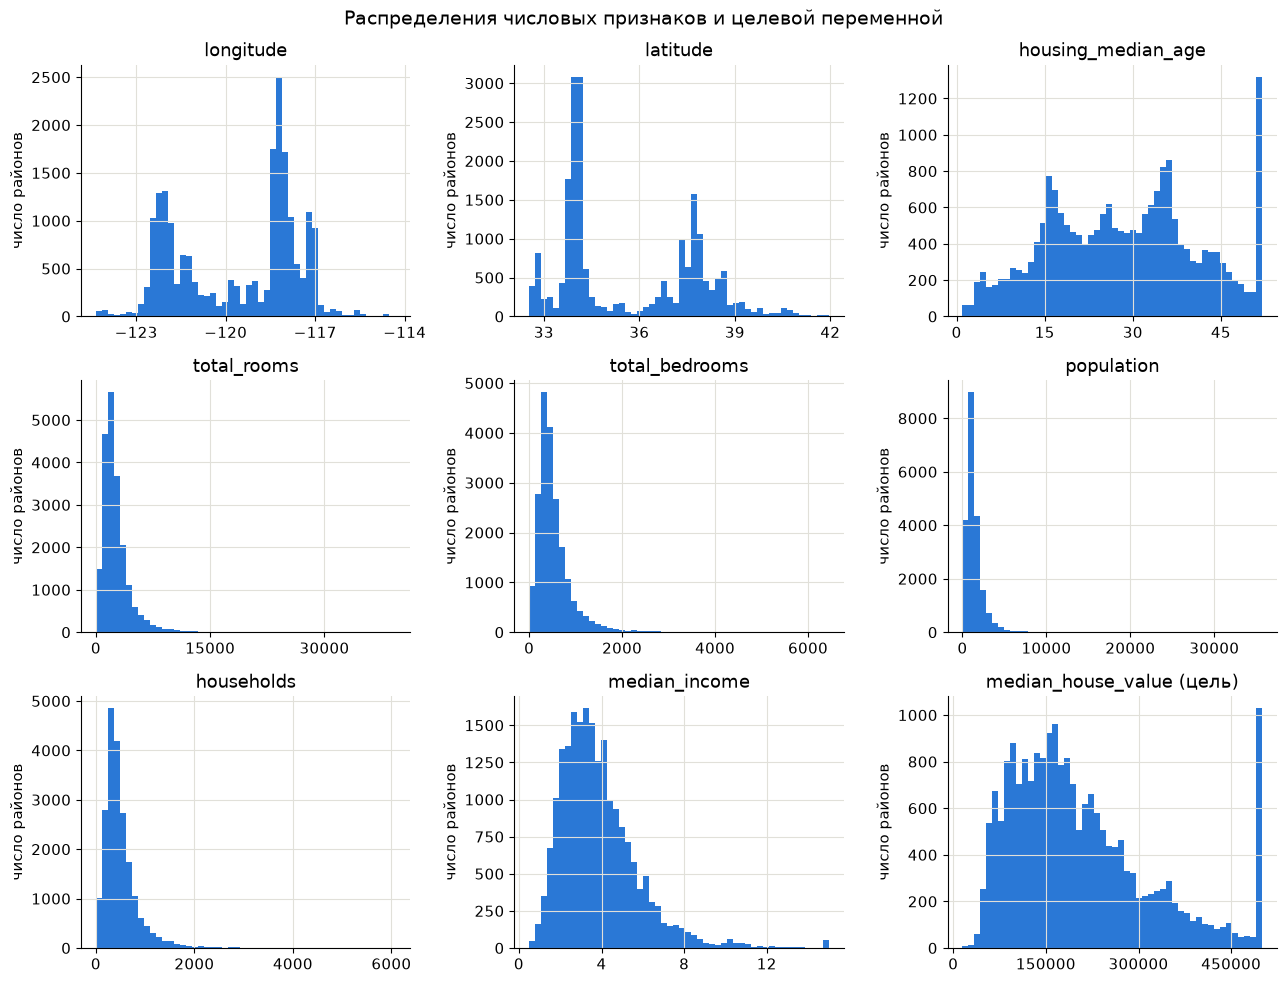

In [8]:
plot_cols = num_features + [TARGET]
display(df[plot_cols].skew().round(2).to_frame('коэффициент асимметрии'))
df[plot_cols].skew().round(6).to_frame('коэффициент асимметрии').to_csv('Результаты/асимметрия.csv', encoding='utf-8')

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df[col].dropna(), bins=50, color=BLUE)
    ax.set_title(col)
    ax.set_ylabel('число районов')
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
axes[2, 2].set_title(TARGET + ' (цель)')
fig.suptitle('Распределения числовых признаков и целевой переменной', fontsize=14)
fig.tight_layout()
fig.savefig('Рисунки/01_распределения.png', dpi=200, bbox_inches='tight')
plt.show()

Счётные признаки `total_rooms`, `total_bedrooms`, `population`, `households` сосредоточены у малых значений и
имеют длинный правый хвост (коэффициенты асимметрии от 3,41 до 4,94), у `median_income` асимметрия меньше (1,65),
у цели — 0,98. У `housing_median_age` и у цели на правом краю стоит отдельный высокий столбец — это срезы 52 года
и 500 001 долл. Долгота и широта имеют по два пика: районы сосредоточены в двух областях — около −118° и 34° с. ш.
(Лос-Анджелес) и около −122° и 38° с. ш. (область залива Сан-Франциско), это видно и на карте ниже. Распределения
далеки от нормального, а масштабы признаков различаются на порядки — это учитывается при анализе выбросов и при
стандартизации.

,районов,"доля, %"
ocean_proximity,,
<1H OCEAN,9136,44.26
INLAND,6551,31.74
NEAR OCEAN,2658,12.88
NEAR BAY,2290,11.09
ISLAND,5,0.02


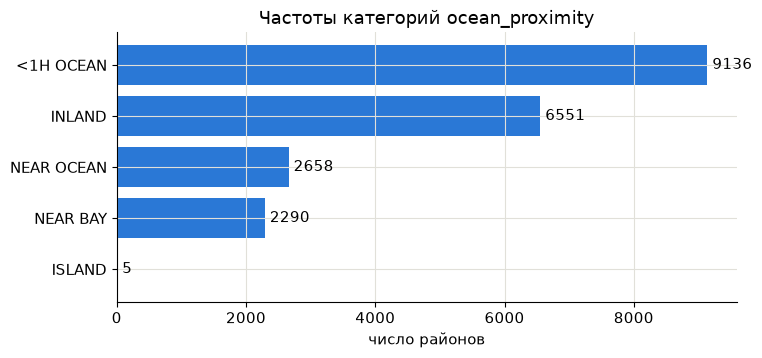

In [9]:
counts = df['ocean_proximity'].value_counts()
display(pd.DataFrame({'районов': counts, 'доля, %': (counts / len(df) * 100).round(2)}))
pd.DataFrame({'районов': counts, 'доля, %': counts / len(df) * 100}).to_csv('Результаты/ocean_proximity.csv', encoding='utf-8')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(counts.index[::-1], counts.values[::-1], color=BLUE)
for i, value in enumerate(counts.values[::-1]):
    ax.text(value + 80, i, str(value), va='center')
ax.set_xlabel('число районов')
ax.set_title('Частоты категорий ocean_proximity')
fig.savefig('Рисунки/02_ocean_proximity.png', dpi=200, bbox_inches='tight')
plt.show()

`ocean_proximity` — номинальный признак из пяти категорий без естественного порядка. Больше всего районов в
категориях `<1H OCEAN` (9 136, 44,26 %) и `INLAND` (6 551, 31,74 %), далее `NEAR OCEAN` (2 658, 12,88 %) и
`NEAR BAY` (2 290, 11,09 %). Категория `ISLAND` очень редкая — 5 районов (0,02 %): при разбиении на выборки и
фолды кросс-валидации её может не оказаться в обучающей части, это учтено при кодировании (раздел 3.3).

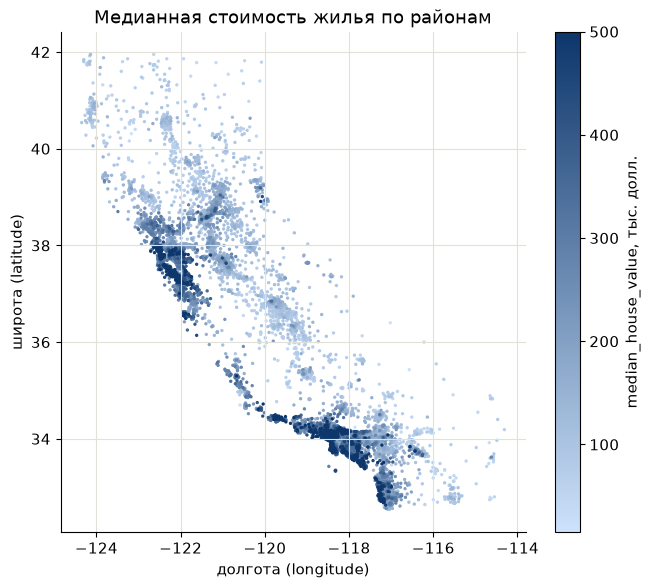

In [10]:
order = df[TARGET].sort_values().index
fig, ax = plt.subplots(figsize=(7.5, 6.5))
points = ax.scatter(df.loc[order, 'longitude'], df.loc[order, 'latitude'],
                    c=df.loc[order, TARGET] / 1000, s=2, cmap=SEQ)
fig.colorbar(points, ax=ax, label='median_house_value, тыс. долл.')
ax.set_xlabel('долгота (longitude)')
ax.set_ylabel('широта (latitude)')
ax.set_title('Медианная стоимость жилья по районам')
fig.savefig('Рисунки/03_карта_цен.png', dpi=200, bbox_inches='tight')
plt.show()

Карта построена по координатам районов, цвет точки — медианная цена. Дорогие районы (тёмные точки) расположены
вдоль побережья, особенно в областях Сан-Франциско и Лос-Анджелеса, внутренние районы в основном дешевле. Соседние
точки обычно близки по цвету: цена зависит от местоположения, и районы, расположенные рядом, похожи. Это важно для
выбора способа разбиения выборки (раздел 3.2).

### 2.4. Выбросы

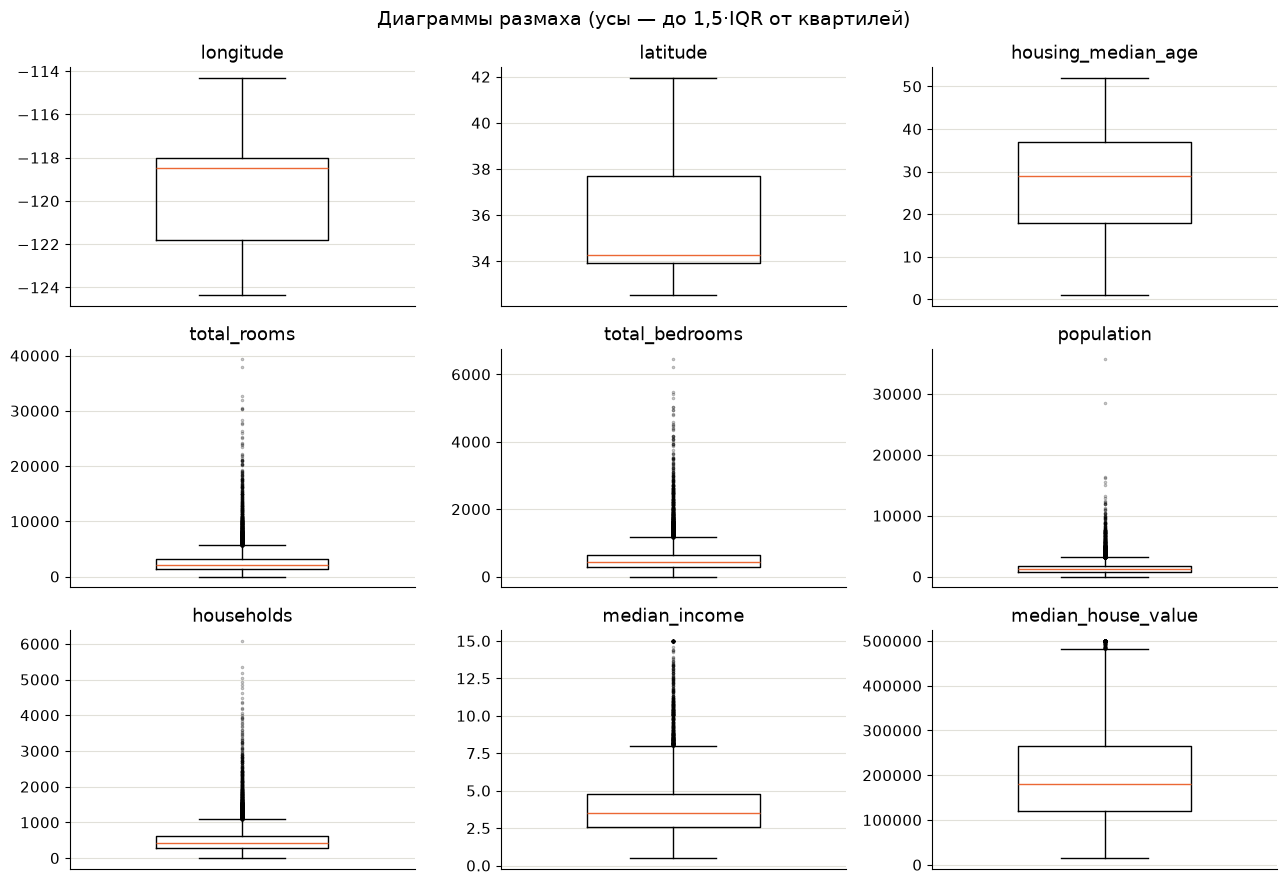

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.boxplot(df[col].dropna(), whis=1.5, widths=0.5,
               flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.3})
    ax.set_title(col)
    ax.set_xticks([])
fig.suptitle('Диаграммы размаха (усы — до 1,5·IQR от квартилей)', fontsize=14)
fig.tight_layout()
fig.savefig('Рисунки/04_диаграммы_размаха.png', dpi=200, bbox_inches='tight')
plt.show()

На диаграмме размаха ящик — межквартильный размах IQR = Q3 − Q1, линия внутри — медиана, усы доходят до самых
дальних значений в пределах 1,5·IQR от квартилей, точки за усами — выбросы по этому правилу (`whis=1.5`).
У координат и возраста домов выбросов нет. У четырёх счётных признаков и у дохода выбросы есть только сверху и
их много — это длинный правый хвост распределения. У цели точки за верхним усом — районы с ценой выше
482 412,5 долл., включая срез 500 001.

In [12]:
rows = []
for col in plot_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    rows.append({'признак': col, 'Q1': q1, 'Q3': q3, 'нижняя граница': low, 'верхняя граница': high,
                 'выбросов': n_out, 'доля, %': n_out / df[col].notna().sum() * 100})
outliers = pd.DataFrame(rows).set_index('признак')
display(outliers.round(2))
outliers.round(6).to_csv('Результаты/выбросы.csv', encoding='utf-8')

any_outlier = np.zeros(len(df), dtype=bool)
for col in plot_cols:
    any_outlier |= ((df[col] < outliers.loc[col, 'нижняя граница']) |
                    (df[col] > outliers.loc[col, 'верхняя граница'])).to_numpy()
print('Строк хотя бы с одним выбросом:', any_outlier.sum(), f'({any_outlier.mean() * 100:.1f} %)')

,Q1,Q3,нижняя граница,верхняя граница,выбросов,"доля, %"
признак,,,,,,
longitude,-121.80,-118.01,-127.48,-112.33,0,0.00
latitude,33.93,37.71,28.26,43.38,0,0.00
housing_median_age,18.00,37.00,-10.50,65.50,0,0.00
total_rooms,1447.75,3148.00,-1102.62,5698.38,1287,6.24
total_bedrooms,296.00,647.00,-230.50,1173.50,1271,6.22
population,787.00,1725.00,-620.00,3132.00,1196,5.79
households,280.00,605.00,-207.50,1092.50,1220,5.91
median_income,2.56,4.74,-0.71,8.01,681,3.30
median_house_value,119600.00,264725.00,-98087.50,482412.50,1071,5.19


Строк хотя бы с одним выбросом: 3019 (14.6 %)


По правилу 1,5·IQR выброс — значение ниже Q1 − 1,5·IQR или выше Q3 + 1,5·IQR. Таких значений: `total_rooms` —
1 287 (6,24 %), `total_bedrooms` — 1 271 (6,22 %), `population` — 1 196 (5,79 %), `households` — 1 220 (5,91 %),
`median_income` — 681 (3,30 %), цель — 1 071 (5,19 %); у координат и возраста домов — 0. Хотя бы один выброс есть
в 3 019 строках (14,6 %). Для нормального распределения за границы 1,5·IQR выходит около 0,7 % значений, а у
счётных признаков — около 6 %, то есть правило отмечает длинный хвост распределения, а не отдельные редкие точки.
Нижние границы у счётных признаков отрицательные, поэтому все их выбросы — крупные районы.

In [13]:
checks = pd.Series({
    'спален больше, чем комнат (total_bedrooms > total_rooms)': (df['total_bedrooms'] > df['total_rooms']).sum(),
    'домохозяйств больше, чем жителей (households > population)': (df['households'] > df['population']).sum(),
    'отрицательные значения (кроме долготы)': (df[plot_cols].drop(columns='longitude') < 0).sum().sum(),
}, name='строк')
display(checks.to_frame())
display(df[df['households'] > df['population']])
print('Наибольшее число комнат на одно домохозяйство:', round((df['total_rooms'] / df['households']).max(), 1))

,строк
"спален больше, чем комнат (total_bedrooms > total_rooms)",0
"домохозяйств больше, чем жителей (households > population)",3
отрицательные значения (кроме долготы),0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5342,-118.44,34.04,16.0,18.0,6.0,3.0,4.0,0.5360,350000.0,<1H OCEAN
11849,-121.00,39.75,8.0,1116.0,214.0,27.0,39.0,2.5893,83000.0,INLAND
19522,-121.00,37.65,17.0,484.0,202.0,198.0,204.0,0.6825,187500.0,INLAND


Наибольшее число комнат на одно домохозяйство: 141.9


Чтобы отличить ошибки от редких, но возможных значений, проверены логические ограничения. Спален больше, чем
комнат, нет ни в одной строке, отрицательных значений (кроме долготы) нет. В 3 строках домохозяйств больше, чем
жителей (например, 4 домохозяйства при 3 жителях), — так быть не может, потому что в домохозяйстве живёт хотя бы
один человек; эти строки считаются ошибочными и удаляются в разделе 3. Большие значения счётных признаков
соответствуют большим районам, а максимум 141,9 комнаты на домохозяйство возможен в районе с большим числом
пустующих домов (в описании набора в scikit-learn так объясняются большие средние числа комнат, например для
курортных районов).

**Решение по выбросам.** Значения за границами 1,5·IQR не удаляются и не заменяются: они не противоречат смыслу
признаков, правило для скошенных распределений отмечает весь правый хвост, а удаление затронуло бы 14,6 % строк
и исключило бы из модели самые крупные и самые богатые районы. Срезанные значения цели (500 001) тоже оставлены:
это реальные дорогие районы, без них проверка модели не охватывала бы верхний сегмент цен; их влияние разобрано
в разделе 6. Удаляются только строки с пропусками (их удаление требует задание) и 3 противоречивые строки.

## 3. Предобработка данных
### 3.1. Удаление пропусков

In [14]:
df_clean = df.dropna()
print('Строк до удаления пропусков:', len(df))
print('После удаления пропусков:', len(df_clean), f'(удалено {len(df) - len(df_clean)})')

bad = df_clean['households'] > df_clean['population']
df_clean = df_clean[~bad]
print('После удаления противоречивых записей:', len(df_clean), f'(удалено {bad.sum()})')

Строк до удаления пропусков: 20640
После удаления пропусков: 20433 (удалено 207)
После удаления противоречивых записей: 20430 (удалено 3)


Пропуски удалены методом `dropna()`, как требует задание: из 20 640 строк осталось 20 433 (удалено 207, то есть
1,0 % данных). Так как значения `total_bedrooms` удалялись случайно, удаление этих строк не должно смещать выборку.
Затем убраны 3 строки, в которых домохозяйств больше, чем жителей. Для работы остаётся 20 430 наблюдений.

In [15]:
X = df_clean[num_features + cat_features]
y = df_clean[TARGET]
print('X:', X.shape, ' y:', y.shape)

X: (20430, 9)  y: (20430,)


Матрица признаков `X` содержит 20 430 строк и 9 столбцов (8 числовых признаков и `ocean_proximity`), вектор
`y` — 20 430 значений цены. Кодирование и масштабирование к `X` здесь не применяются: они войдут в конвейер
`Pipeline` и будут обучаться только на обучающей выборке.

### 3.2. Разделение на обучающую и тестовую выборки

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Обучающая выборка:', X_train.shape, ' тестовая:', X_test.shape)
print(f'Средняя цена: train {y_train.mean():.0f}, test {y_test.mean():.0f} долл.')
print(f'Доля районов с ценой 500 001: train {(y_train == 500_001).mean() * 100:.2f} %, '
      f'test {(y_test == 500_001).mean() * 100:.2f} %')
print('Районов ISLAND: train', (X_train['ocean_proximity'] == 'ISLAND').sum(),
      ' test', (X_test['ocean_proximity'] == 'ISLAND').sum())

Обучающая выборка: (16344, 9)  тестовая: (4086, 9)
Средняя цена: train 206679, test 207608 долл.
Доля районов с ценой 500 001: train 4.64 %, test 4.89 %
Районов ISLAND: train 4  test 1


`train_test_split` с `test_size=0.2` делит данные в пропорции 80/20: 16 344 района в обучающей выборке и 4 086 в
тестовой. `random_state=42` фиксирует случайное перемешивание строк перед делением. Выборки получились похожими:
средняя цена 206 679 и 207 608 долл., доля районов со срезанной ценой 4,64 % и 4,89 %. Из пяти районов `ISLAND`
четыре попали в обучающую выборку и один в тестовую. Тестовая выборка дальше используется только для итоговой
оценки моделей.

In [17]:
_, X_test_same, _, _ = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
_, X_test_other, _, _ = train_test_split(X, y, test_size=0.2, random_state=0)
print('random_state=42 повторно — та же тестовая выборка:', X_test_same.index.equals(X_test.index))
print('random_state=0 — общих районов с исходной тестовой выборкой:',
      X_test.index.isin(X_test_other.index).sum(), 'из', len(X_test))

random_state=42 повторно — та же тестовая выборка: True
random_state=0 — общих районов с исходной тестовой выборкой: 849 из 4086


`random_state` задаёт начальное состояние генератора случайных чисел, которым перемешиваются строки. При том же
значении 42 получается та же тестовая выборка (проверка дала `True`), поэтому результаты воспроизводимы. При
`random_state=0` с исходной тестовой выборкой совпадают только 849 районов из 4 086 (20,8 % — примерно столько и
должно совпадать при случайном выборе 20 % строк): получились бы другие выборки и немного другие метрики. Насколько
меняются метрики, показано в разделе 5.5.

In [18]:
nn = NearestNeighbors(n_neighbors=1).fit(X_train[['latitude', 'longitude']])
dist, idx = nn.kneighbors(X_test[['latitude', 'longitude']])
neighbour_price = y_train.to_numpy()[idx[:, 0]]
neighbour_corr = np.corrcoef(y_test, neighbour_price)[0, 1]
same_coords = (dist[:, 0] == 0).mean() * 100
print(f'Корреляция цены тестового района и ближайшего к нему района из train: {neighbour_corr:.3f}')
print(f'Тестовых районов, у которых в train есть район с теми же координатами: {same_coords:.1f} %')

Корреляция цены тестового района и ближайшего к нему района из train: 0.862
Тестовых районов, у которых в train есть район с теми же координатами: 54.9 %


Подходит ли случайное разбиение? Временного порядка в данных нет — все записи относятся к одной переписи 1990 г.;
каждая строка описывает отдельную блок-группу, повторных наблюдений одного объекта нет (полных дубликатов тоже
нет). Но районы связаны пространственно: цена тестового района и ближайшего к нему района из обучающей выборки
коррелируют с r = 0,862, а у 54,9 % тестовых районов в обучающей выборке есть район с теми же координатами
(координаты записаны с точностью 0,01°). Поэтому случайное разбиение оценивает качество прогноза для новых районов
на уже знакомой модели территории. Для переноса модели на другую территорию такая оценка была бы оптимистичной —
тогда выборку нужно делить по участкам карты.

### 3.3. Кодирование категориального признака

In [19]:
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_features])
print('Категории:', list(encoder.categories_[0]))
print('Базовая (удалённая) категория:', encoder.categories_[0][encoder.drop_idx_[0]])
example = pd.DataFrame({'ocean_proximity': encoder.categories_[0]})
display(pd.DataFrame(encoder.transform(example), index=example['ocean_proximity'],
                     columns=encoder.get_feature_names_out()).astype(int))

Категории: ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']
Базовая (удалённая) категория: <1H OCEAN


,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
ocean_proximity,,,,
<1H OCEAN,0,0,0,0
INLAND,1,0,0,0
ISLAND,0,1,0,0
NEAR BAY,0,0,1,0
NEAR OCEAN,0,0,0,1


Категориальный признак один — `ocean_proximity`. Он номинальный: категории не упорядочены (нельзя сказать, что
`INLAND` «больше» `NEAR BAY`), поэтому кодирование числами 0–4 ввело бы в линейную модель несуществующий порядок
и одинаковые «шаги» между категориями. Использовано one-hot кодирование: для категории создаётся отдельный столбец
из нулей и единиц. Параметр `drop='first'` удаляет столбец первой категории `<1H OCEAN` — она становится базовой
(все нули): иначе сумма пяти столбцов всегда равна 1 и полностью повторяет свободный член (точная
мультиколлинеарность). Коэффициент каждого из четырёх оставшихся столбцов показывает разницу в цене по сравнению
с `<1H OCEAN`. `handle_unknown='ignore'` нужен из-за редкой категории `ISLAND` (4 района в обучающей выборке):
если в обучающей части какого-либо разбиения её не окажется, то на проверочной части неизвестная категория не
вызовет ошибку, а будет закодирована нулями. `sparse_output=False` возвращает обычный массив вместо разреженной
матрицы.

### 3.4. Масштабирование: fit, transform и fit_transform

In [20]:
scaler = StandardScaler()
scaler.fit(X_train[num_features])
train_scaled = scaler.transform(X_train[num_features])
test_scaled = scaler.transform(X_test[num_features])
scaling = pd.DataFrame({'среднее (fit)': scaler.mean_, 'СКО (fit)': scaler.scale_,
                        'среднее train после': train_scaled.mean(axis=0),
                        'СКО train после': train_scaled.std(axis=0),
                        'среднее test после': test_scaled.mean(axis=0),
                        'СКО test после': test_scaled.std(axis=0)}, index=num_features)
display(scaling.round(3))
scaling.round(6).to_csv('Результаты/стандартизация.csv', encoding='utf-8')
same = np.allclose(StandardScaler().fit_transform(X_train[num_features]), train_scaled)
print('fit_transform(train) даёт то же, что fit(train) + transform(train):', same)

,среднее (fit),СКО (fit),среднее train после,СКО train после,среднее test после,СКО test после
longitude,-119.578,2.007,-0.0,1.0,0.020,0.993
latitude,35.639,2.138,0.0,1.0,-0.013,0.996
housing_median_age,28.597,12.613,-0.0,1.0,0.015,0.991
total_rooms,2629.011,2169.136,0.0,1.0,0.018,1.036
total_bedrooms,537.314,421.724,-0.0,1.0,0.007,0.996
population,1422.864,1136.633,0.0,1.0,0.010,0.985
households,498.768,382.254,-0.0,1.0,0.010,1.000
median_income,3.870,1.896,-0.0,1.0,0.003,1.008


fit_transform(train) даёт то же, что fit(train) + transform(train): True


Масштабируются все восемь числовых признаков (стандартизация `StandardScaler`), фиктивные столбцы
`ocean_proximity` остаются нулями и единицами. `fit` вычисляет и запоминает параметры преобразования — среднее
(`mean_`) и стандартное отклонение, СКО (`scale_`), каждого признака по обучающей выборке. `transform` применяет
запомненные параметры: $z = (x - \bar x) / s$. `fit_transform` выполняет оба шага одним вызовом, результат совпадает
с `fit` + `transform` (проверка дала `True`). После преобразования у обучающей выборки среднее ровно 0 и СКО 1, а у
тестовой — только приблизительно (средние от −0,013 до 0,020, СКО от 0,985 до 1,036), так как она преобразована
параметрами обучающей выборки. Так и должно быть: тестовые данные не участвуют в настройке, иначе сведения о них
попали бы в модель.

### 3.5. Предобработка в ColumnTransformer

In [21]:
def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features),
    ], verbose_feature_names_out=False)

prep = make_preprocessor().fit(X_train)
X_train_prep = pd.DataFrame(prep.transform(X_train), columns=prep.get_feature_names_out(),
                            index=X_train.index)
print('Матрица признаков: до предобработки', X_train.shape, '-> после', X_train_prep.shape)
print(list(X_train_prep.columns))
print('Средние в StandardScaler равны средним train:',
      np.allclose(prep.named_transformers_['num'].mean_, X_train[num_features].mean()))

Матрица признаков: до предобработки (16344, 9) -> после (16344, 12)
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Средние в StandardScaler равны средним train: True


`ColumnTransformer` объединяет две предобработки: `StandardScaler` для восьми числовых признаков и `OneHotEncoder`
для `ocean_proximity`. После обучения на `X_train` матрица признаков имеет 12 столбцов (8 стандартизованных и
4 фиктивных), размер 16 344 × 12. Средние, запомненные в `StandardScaler`, совпадают со средними обучающей выборки
— тестовая выборка в настройке не участвовала. Функция `make_preprocessor()` при каждом вызове создаёт новый,
необученный объект, поэтому у каждой модели своя предобработка. Масштабирование нужно, так как признаки
различаются по масштабу на порядки: штраф лассо и гребневой регрессии зависит от величины коэффициентов, а значит,
от масштаба признаков, а PCA — от их дисперсий. Матрица `X_train_prep` используется для расчёта VIF и путей
коэффициентов.

## 4. Матрица корреляций и мультиколлинеарность
### 4.1. Матрица корреляций

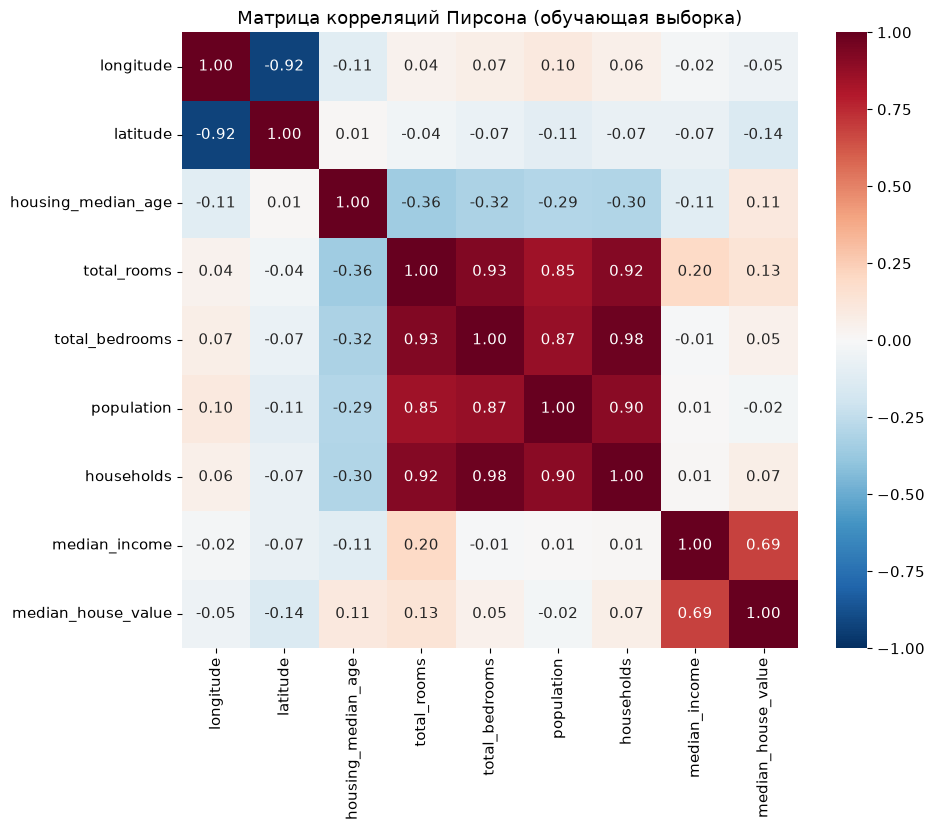

In [22]:
train_df = pd.concat([X_train[num_features], y_train], axis=1)
corr = train_df.corr(method='pearson')
corr.round(6).to_csv('Результаты/корреляции_пирсон.csv', encoding='utf-8')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=ax)
ax.grid(False)
ax.set_title('Матрица корреляций Пирсона (обучающая выборка)')
fig.savefig('Рисунки/05_корреляции.png', dpi=200, bbox_inches='tight')
plt.show()

Матрица корреляций Пирсона построена по обучающей выборке для восьми числовых признаков и цели; категориальный
признак в расчёт не входит, так как коэффициент Пирсона определён для числовых переменных. На диагонали единицы
(корреляция признака с самим собой). Видны два блока сильно связанных признаков: четыре «размерных» признака
`total_rooms`, `total_bedrooms`, `population`, `households` (r от 0,85 до 0,98) и пара координат (r = −0,92). С ценой
заметно связан только медианный доход (r = 0,69), остальные признаки связаны с ценой слабо (|r| ≤ 0,14).

In [23]:
corr_s = train_df.corr(method='spearman')
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = pd.DataFrame({'Пирсон': corr.where(mask).stack(),
                      'Спирмен': corr_s.where(mask).stack()}).dropna()
pairs = pairs.loc[pairs['Пирсон'].abs().sort_values(ascending=False).index]
display(pairs.head(10).round(3))
pairs.round(6).to_csv('Результаты/пары_корреляций.csv', encoding='utf-8')
print('Наибольшее расхождение коэффициентов Пирсона и Спирмена:', round((corr - corr_s).abs().max().max(), 3))

Пирсон  Спирмен
total_bedrooms     households           0.979    0.976
total_rooms        total_bedrooms       0.929    0.915
longitude          latitude            -0.925   -0.878
total_rooms        households           0.917    0.906
population         households           0.902    0.902
total_bedrooms     population           0.871    0.869
total_rooms        population           0.851    0.815
median_income      median_house_value   0.686    0.673
housing_median_age total_rooms         -0.359   -0.356
                   total_bedrooms      -0.319   -0.308

Наибольшее расхождение коэффициентов Пирсона и Спирмена: 0.074


Основной метод — коэффициент корреляции Пирсона: он измеряет силу именно линейной связи, а мультиколлинеарность
в линейной регрессии и VIF определяются линейной зависимостью признаков. Для проверки посчитан коэффициент
Спирмена (корреляция рангов, он улавливает любую монотонную связь и мало чувствителен к выбросам). Он даёт те же
сильные пары; наибольшее расхождение — 0,074 (пара `total_rooms`–`median_income`: 0,198 по Пирсону и 0,272 по
Спирмену), на выводы это не влияет. Самые сильные пары: `total_bedrooms`–`households` (0,979),
`total_rooms`–`total_bedrooms` (0,929), `longitude`–`latitude` (−0,925), `total_rooms`–`households` (0,917),
`population`–`households` (0,902). Четыре «размерных» признака растут вместе: чем больше в районе домохозяйств,
тем больше комнат, спален и жителей. Сильная отрицательная связь координат соответствует форме штата, вытянутого
с северо-запада на юго-восток (карта в разделе 2.3).

,r с ценой
median_income,0.686
latitude,-0.141
total_rooms,0.134
housing_median_age,0.107
households,0.067
total_bedrooms,0.052
longitude,-0.048
population,-0.024


Районов с доходом выше 10: 241, доля среди них районов с ценой 500 001: 85.1 %


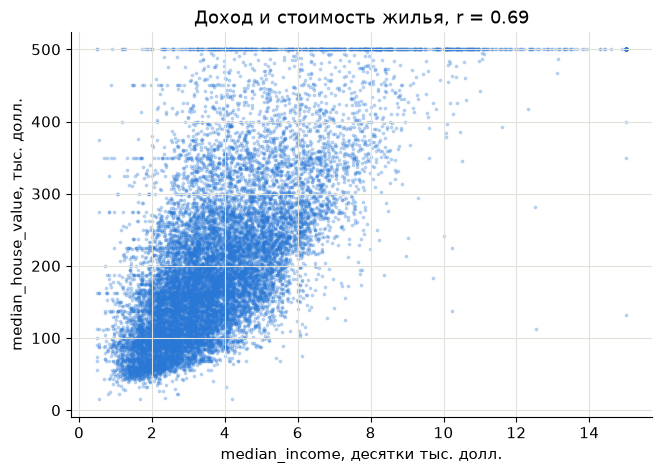

In [24]:
target_corr = corr[TARGET].drop(TARGET)
display(target_corr.loc[target_corr.abs().sort_values(ascending=False).index].round(3).to_frame('r с ценой'))
rich = X_train['median_income'] > 10
print(f'Районов с доходом выше 10: {rich.sum()}, доля среди них районов с ценой 500 001: '
      f'{(y_train[rich] == 500_001).mean() * 100:.1f} %')

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(X_train['median_income'], y_train / 1000, s=3, alpha=0.25, color=BLUE)
ax.set_xlabel('median_income, десятки тыс. долл.')
ax.set_ylabel('median_house_value, тыс. долл.')
ax.set_title(f'Доход и стоимость жилья, r = {corr.loc["median_income", TARGET]:.2f}')
fig.savefig('Рисунки/06_доход_и_цена.png', dpi=200, bbox_inches='tight')
plt.show()

С ценой сильнее всего связан медианный доход (r = 0,686): на диаграмме рассеяния с ростом дохода цена в среднем
растёт, но разброс велик. С остальными признаками связь слабая: широта −0,141, `total_rooms` 0,134, возраст
домов 0,107, у остальных |r| < 0,07. Слабая парная корреляция не значит, что признак бесполезен: по отдельности
координаты почти не связаны с ценой, но на карте влияние местоположения хорошо видно. На диаграмме заметна
горизонтальная линия на уровне 500 тыс. долл. — срез цели: среди 241 района с доходом выше 10 у 85,1 % цена равна
500 001, поэтому при высоком доходе линейный рост цены обрывается.

### 4.2. Коэффициенты VIF

In [25]:
def vif_table(data):
    exog = add_constant(data)
    values = [variance_inflation_factor(exog.values, i) for i in range(1, exog.shape[1])]
    return pd.Series(values, index=data.columns)

vif = pd.DataFrame({'VIF (числовые признаки)': vif_table(X_train_prep[num_features]),
                    'VIF (все признаки модели)': vif_table(X_train_prep)})
display(vif.round(2))
vif.round(6).to_csv('Результаты/vif.csv', encoding='utf-8')

,VIF (числовые признаки),VIF (все признаки модели)
households,33.73,33.77
housing_median_age,1.26,1.32
latitude,8.82,20.01
longitude,8.73,18.16
median_income,1.71,1.77
ocean_proximity_INLAND,NaN,2.86
ocean_proximity_ISLAND,NaN,1.00
ocean_proximity_NEAR BAY,NaN,1.58
ocean_proximity_NEAR OCEAN,NaN,1.20
population,6.02,6.09


VIF признака $x_j$ равен $1/(1-R_j^2)$, где $R_j^2$ — коэффициент детерминации регрессии $x_j$ на все остальные
признаки. В функцию `variance_inflation_factor` передаются матрица признаков обучающей выборки с добавленным
столбцом единиц (`add_constant`) и номер столбца. Константа нужна, потому что модели строятся со свободным членом;
стандартизация VIF не меняет, поэтому взяты уже преобразованные признаки `X_train_prep`. Результаты по числовым
признакам: `total_bedrooms` — 35,00, `households` — 33,73, `total_rooms` — 12,39, `latitude` — 8,82,
`longitude` — 8,73, `population` — 6,02, `median_income` — 1,71, `housing_median_age` — 1,26.

Интерпретация: по лекции VIF ≈ 1 означает отсутствие мультиколлинеарности, VIF > 3 — её наличие, VIF > 10 —
серьёзную мультиколлинеарность; в документации statsmodels и во многих источниках используется порог 5. По любому
из этих правил у трёх «размерных» признаков мультиколлинеарность серьёзная, у координат и населения — заметная,
у дохода и возраста домов её нет. VIF = 35 у `total_bedrooms` означает, что 97 % его дисперсии ($R^2 = 1 - 1/35$)
объясняется другими признаками, а дисперсия оценки его коэффициента в 35 раз больше, чем была бы при
некоррелированных признаках. Пороги условны: O'Brien (2007) показывает, что их нельзя применять механически —
влияние высокого VIF на точность оценок может компенсироваться большим объёмом выборки (в обучающей выборке
16 344 наблюдения).
Во втором столбце VIF посчитан по всем 12 признакам модели: вместе с фиктивными признаками `ocean_proximity` VIF
координат вырастает до 20,01 и 18,16, так как категории близости к океану тоже описывают местоположение.

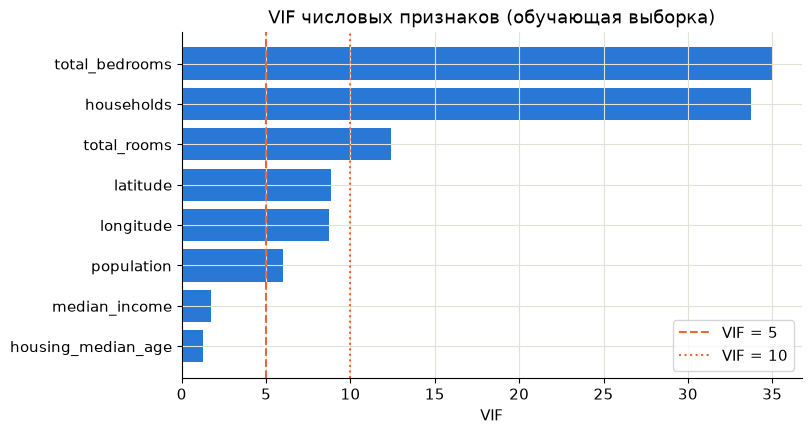

In [26]:
vif_num = vif['VIF (числовые признаки)'].dropna().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(vif_num.index, vif_num.values, color=BLUE)
ax.axvline(5, color=ORANGE, ls='--', label='VIF = 5')
ax.axvline(10, color=ORANGE, ls=':', label='VIF = 10')
ax.set_xlabel('VIF')
ax.set_title('VIF числовых признаков (обучающая выборка)')
ax.legend()
fig.savefig('Рисунки/07_vif.png', dpi=200, bbox_inches='tight')
plt.show()

На диаграмме VIF числовых признаков упорядочены по возрастанию, вертикальные линии — пороги 5 и 10. За порог 10
выходят `total_bedrooms`, `households` и `total_rooms`, между 5 и 10 находятся координаты и `population`, ниже 5 —
доход и возраст домов.

In [27]:
reduced = [col for col in num_features if col not in ('total_bedrooms', 'households')]
vif_reduced = vif_table(X_train_prep[reduced])
display(vif_reduced.round(2).to_frame('VIF без total_bedrooms и households'))
vif_reduced.round(6).to_frame('VIF без total_bedrooms и households').to_csv('Результаты/vif_без_двух.csv', encoding='utf-8')

,VIF без total_bedrooms и households
longitude,8.21
latitude,8.30
housing_median_age,1.26
total_rooms,4.50
population,4.26
median_income,1.29


Предложение по признакам: `total_bedrooms` и `households` почти линейно выражаются через другие «размерные»
признаки (корреляция между ними 0,979, VIF 35,00 и 33,73), их можно удалить или заменить относительными
показателями (например, комнат и жителей на одно домохозяйство). Проверка: без этих двух признаков VIF оставшихся
ниже 10 (`total_rooms` — 4,50, `population` — 4,26), но у координат остаётся 8,21 и 8,30: уже одна их взаимная
корреляция (−0,925) даёт VIF не меньше $1/(1-r^2) \approx 6{,}9$. Удалять одну из координат нельзя — только вместе
они задают положение района. По заданию
мультиколлинеарность устраняется методом главных компонент (раздел 7), а гребневая и лассо-регрессия ослабляют её
влияние штрафом на коэффициенты, поэтому модели раздела 5 строятся на всех признаках.

## 5. Регрессионные модели на исходных признаках
### 5.1. Схема проверки и сетка alpha

In [28]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
alphas = np.logspace(-2, 5, 29)
print('Проверяемые значения alpha:')
print(alphas.round(3))

Проверяемые значения alpha:
[1.0000000e-02 1.8000000e-02 3.2000000e-02 5.6000000e-02 1.0000000e-01
 1.7800000e-01 3.1600000e-01 5.6200000e-01 1.0000000e+00 1.7780000e+00
 3.1620000e+00 5.6230000e+00 1.0000000e+01 1.7783000e+01 3.1623000e+01
 5.6234000e+01 1.0000000e+02 1.7782800e+02 3.1622800e+02 5.6234100e+02
 1.0000000e+03 1.7782790e+03 3.1622780e+03 5.6234130e+03 1.0000000e+04
 1.7782794e+04 3.1622777e+04 5.6234133e+04 1.0000000e+05]


Для подбора alpha и оценки моделей используется 5-кратная кросс-валидация `KFold(n_splits=5, shuffle=True,
random_state=42)`: обучающая выборка делится на 5 частей (фолдов), модель 5 раз обучается на четырёх частях и
проверяется на пятой. `shuffle=True` перемешивает строки перед делением (в файле соседние строки — соседние районы
с почти одинаковыми координатами, это видно по первым строкам), `random_state` делает деление воспроизводимым.
Сетка `np.logspace(-2, 5, 29)` — 29 значений alpha от 0,01 до 100 000, равномерно на логарифмической шкале
(каждое следующее больше предыдущего в $10^{0,25} \approx 1,78$ раза): проверяются и почти нулевой, и очень
сильный штраф.

### 5.2. Обучение моделей

In [29]:
pipe_lin = Pipeline([('prep', make_preprocessor()), ('model', LinearRegression())])
pipe_lin.fit(X_train, y_train)
pipe_lin

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix an

Линейная регрессия собрана в конвейер `Pipeline` из двух шагов: `prep` — предобработка (`ColumnTransformer`:
стандартизация числовых признаков и one-hot кодирование `ocean_proximity`), `model` — `LinearRegression`, которая
находит коэффициенты методом наименьших квадратов. Метод `fit` конвейера сначала обучает предобработку на
`X_train` и преобразует его, затем обучает модель на преобразованных данных; `predict` применяет к новым данным
уже обученную предобработку (только `transform`) и модель. Благодаря конвейеру при кросс-валидации предобработка
каждый раз обучается только на обучающих фолдах.

In [30]:
grid_lasso = GridSearchCV(Pipeline([('prep', make_preprocessor()), ('model', Lasso())]),
                          param_grid={'model__alpha': alphas}, cv=cv,
                          scoring='neg_root_mean_squared_error')
grid_lasso.fit(X_train, y_train)
print('Лассо: лучшее alpha =', grid_lasso.best_params_['model__alpha'],
      f'; RMSE на кросс-валидации = {-grid_lasso.best_score_:.1f}')
print('Итераций координатного спуска до сходимости:', grid_lasso.best_estimator_.named_steps['model'].n_iter_)

Лассо: лучшее alpha = 0.01 ; RMSE на кросс-валидации = 68976.4
Итераций координатного спуска до сходимости: 405


Лассо-регрессия (`Lasso`) минимизирует $\frac{1}{2n}\sum (y_i - \hat y_i)^2 + \alpha \sum |w_j|$ — к ошибке
добавлен L1-штраф. `GridSearchCV` перебирает 29 значений alpha (`model__alpha` — параметр `alpha` шага `model`),
для каждого выполняет 5-кратную кросс-валидацию и выбирает значение с наименьшей средней RMSE
(`scoring='neg_root_mean_squared_error'`; в scikit-learn ошибки берутся со знаком минус, чтобы большее значение
означало лучшую модель). Затем модель с лучшим alpha переобучается на всей обучающей выборке (`refit=True` по
умолчанию). Лучшим оказалось наименьшее значение сетки alpha = 0,01 (RMSE на кросс-валидации 68 976,4 долл.), то
есть почти без штрафа. Коэффициенты лассо находятся координатным спуском; он сошёлся за 405 итераций при пределе
`max_iter=1000` по умолчанию, поэтому увеличивать предел не понадобилось.

In [31]:
grid_ridge = GridSearchCV(Pipeline([('prep', make_preprocessor()), ('model', Ridge())]),
                          param_grid={'model__alpha': alphas}, cv=cv,
                          scoring='neg_root_mean_squared_error')
grid_ridge.fit(X_train, y_train)
print('Гребневая: лучшее alpha =', grid_ridge.best_params_['model__alpha'],
      f'; RMSE на кросс-валидации = {-grid_ridge.best_score_:.1f}')

Гребневая: лучшее alpha = 31.622776601683793 ; RMSE на кросс-валидации = 68969.9


Гребневая регрессия (`Ridge`) минимизирует $\sum (y_i - \hat y_i)^2 + \alpha \sum w_j^2$ — L2-штраф. Подбор по той
же сетке и на тех же фолдах дал alpha = 31,62 и RMSE 68 969,9 долл. — на 6,5 долл. меньше, чем у лассо, то есть
практически столько же.

In [32]:
models = {'Линейная': pipe_lin, 'Лассо': grid_lasso.best_estimator_, 'Гребневая': grid_ridge.best_estimator_}
for name, model in models.items():
    print(name, model.named_steps['model'].get_params())

Линейная {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Лассо {'alpha': np.float64(0.01), 'copy_X': True, 'fit_intercept': True, 'max_iter': 1000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}
Гребневая {'alpha': np.float64(31.622776601683793), 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}


Явно задано у моделей только `alpha` лассо и гребневой регрессии — оно подобрано по сетке; явно заданы также
параметры разбиения, кросс-валидации, сетки и кодирования (`drop`, `handle_unknown`, `sparse_output`). Остальное
оставлено по умолчанию: свободный член оценивается (`fit_intercept=True`), коэффициенты могут быть любого знака
(`positive=False`), у лассо — не больше 1 000 итераций (`max_iter=1000`) циклического координатного спуска
(`selection='cyclic'`) с точностью остановки `tol=0.0001`, у гребневой способ решения выбирается автоматически
(`solver='auto'`). У `LinearRegression` параметра регуляризации нет, все её параметры — по умолчанию.

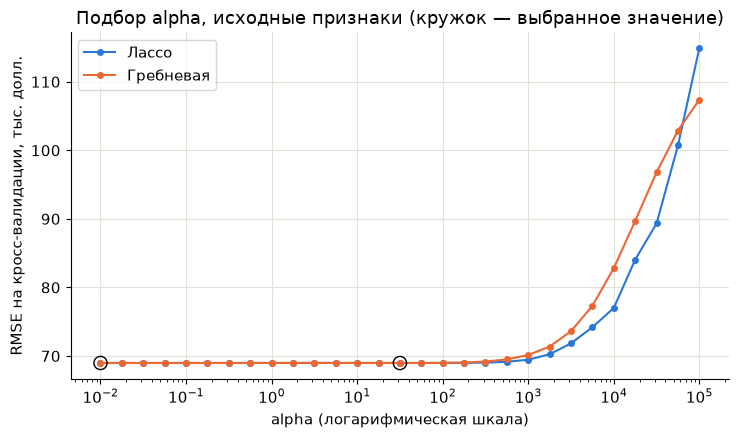

In [33]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for grid, name, color in [(grid_lasso, 'Лассо', BLUE), (grid_ridge, 'Гребневая', ORANGE)]:
    ax.plot(alphas, -grid.cv_results_['mean_test_score'] / 1000, marker='o', markersize=4,
            color=color, label=name)
    ax.scatter(grid.best_params_['model__alpha'], -grid.best_score_ / 1000, s=90,
               facecolor='none', edgecolor='black', zorder=3)
ax.set_xscale('log')
ax.set_xlabel('alpha (логарифмическая шкала)')
ax.set_ylabel('RMSE на кросс-валидации, тыс. долл.')
ax.set_title('Подбор alpha, исходные признаки (кружок — выбранное значение)')
ax.legend()
fig.savefig('Рисунки/08_подбор_alpha.png', dpi=200, bbox_inches='tight')
plt.show()
pd.DataFrame({'alpha': alphas, 'RMSE лассо': -grid_lasso.cv_results_['mean_test_score'],
              'RMSE гребневая': -grid_ridge.cv_results_['mean_test_score']}
             ).to_csv('Результаты/alpha_исходные.csv', index=False, encoding='utf-8')

Кривые RMSE(alpha) обеих моделей почти горизонтальны при alpha от 0,01 до 100 (RMSE от 68 970 до 68 990 долл.) и
круто растут при больших alpha: при alpha = 1 000 RMSE лассо 69 451, гребневой 70 135 долл., при alpha = 100 000 —
114 921 и 107 394 долл. Сильный штраф стягивает коэффициенты к нулю, и модель перестаёт описывать зависимость
(недообучение). Выигрыша от штрафа нет: выбранные значения (кружки) отличаются от соседних на единицы долларов при
разбросе RMSE между фолдами около 1 940 долл. Это согласуется с теорией: штраф уменьшает дисперсию оценок
коэффициентов ценой их смещения и полезен, когда эта дисперсия велика, например при малом числе наблюдений
относительно числа признаков; здесь 16 344 наблюдения на 12 признаков.

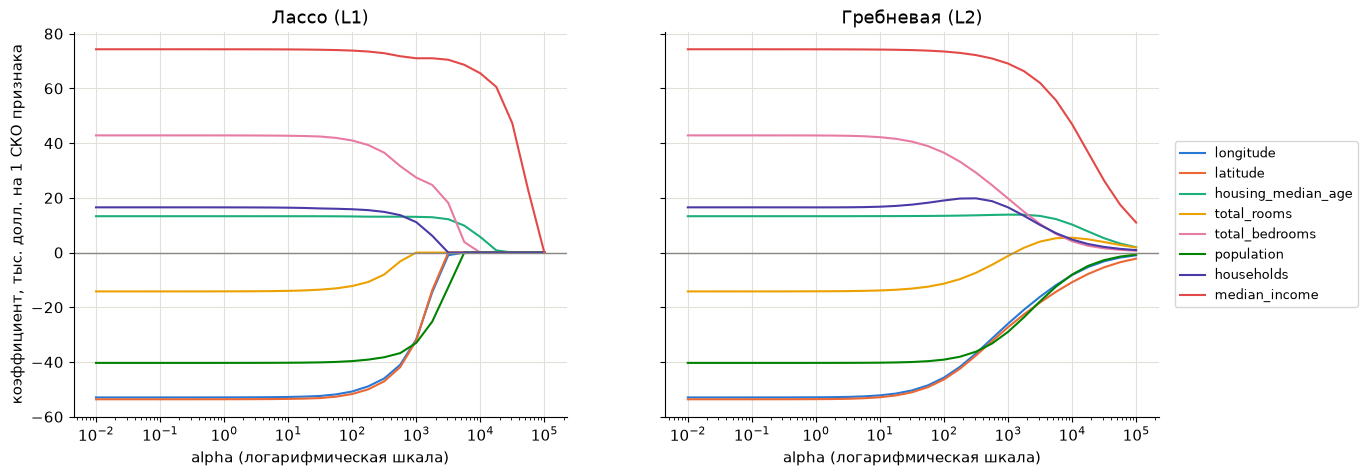

alpha = 0.01: ненулевых коэффициентов лассо 12 из 12, обнулены: []
alpha = 0.1: ненулевых коэффициентов лассо 12 из 12, обнулены: []
alpha = 1: ненулевых коэффициентов лассо 12 из 12, обнулены: []
alpha = 10: ненулевых коэффициентов лассо 12 из 12, обнулены: []
alpha = 100: ненулевых коэффициентов лассо 11 из 12, обнулены: ['ocean_proximity_ISLAND']
alpha = 1000: ненулевых коэффициентов лассо 9 из 12, обнулены: ['total_rooms', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY']
alpha = 10000: ненулевых коэффициентов лассо 3 из 12, обнулены: ['longitude', 'latitude', 'total_rooms', 'total_bedrooms', 'population', 'households', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
alpha = 100000: ненулевых коэффициентов лассо 0 из 12, обнулены: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_pr

In [34]:
COLORS8 = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
path_lasso = pd.DataFrame([Lasso(alpha=a).fit(X_train_prep, y_train).coef_ for a in alphas],
                          index=alphas, columns=X_train_prep.columns)
path_ridge = pd.DataFrame([Ridge(alpha=a).fit(X_train_prep, y_train).coef_ for a in alphas],
                          index=alphas, columns=X_train_prep.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, path, title in [(axes[0], path_lasso, 'Лассо (L1)'), (axes[1], path_ridge, 'Гребневая (L2)')]:
    for col, color in zip(num_features, COLORS8):
        ax.plot(path.index, path[col] / 1000, color=color, label=col)
    ax.axhline(0, color=GRAY, lw=1)
    ax.set_xscale('log')
    ax.set_xlabel('alpha (логарифмическая шкала)')
    ax.set_title(title)
axes[0].set_ylabel('коэффициент, тыс. долл. на 1 СКО признака')
axes[1].legend(fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.savefig('Рисунки/09_пути_коэффициентов.png', dpi=200, bbox_inches='tight')
plt.show()
rows = []
for a in alphas[::4]:
    zero = [col for col in X_train_prep.columns if path_lasso.loc[a, col] == 0]
    print(f'alpha = {a:g}: ненулевых коэффициентов лассо {12 - len(zero)} из 12, обнулены: {zero}')
    rows.append({'alpha': a, 'ненулевых': 12 - len(zero), 'обнулены': ', '.join(zero)})
pd.DataFrame(rows).to_csv('Результаты/лассо_нули.csv', index=False, encoding='utf-8')

Пути коэффициентов показывают, как штраф меняет модель (коэффициенты числовых признаков в тысячах долларов на одно
СКО признака; для каждого alpha из сетки модель обучена на всей обучающей выборке). У лассо (L1) коэффициенты по
очереди становятся точно нулевыми: при alpha ≤ 10 ненулевые все 12, при alpha = 100 обнуляется
`ocean_proximity_ISLAND`, при 1 000 — ещё `total_rooms` и `ocean_proximity_NEAR BAY` (остаётся 9), при 10 000
остаются только `median_income`, `housing_median_age` и `ocean_proximity_INLAND`, при 100 000 — ни одного. У
гребневой (L2) коэффициенты плавно уменьшаются к нулю, но точно нулевыми не становятся. В этом и состоит различие
L1 и L2: лассо отбирает признаки, гребневая только сжимает коэффициенты. При выбранных по кросс-валидации alpha
(0,01 и 31,6) штраф слабый, поэтому коэффициенты почти не отличаются от обычной регрессии (раздел 5.4).

### 5.3. Кросс-валидация

In [35]:
scoring = {'rmse': 'neg_root_mean_squared_error', 'r2': 'r2', 'mape': 'neg_mean_absolute_percentage_error'}

def cv_table(models):
    rows = {}
    for name, model in models.items():
        s = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
        rows[name] = {'RMSE': -s['test_rmse'].mean(), 'RMSE ±': s['test_rmse'].std(),
                      'R2': s['test_r2'].mean(), 'R2 ±': s['test_r2'].std(),
                      'MAPE, %': -s['test_mape'].mean() * 100, 'MAPE ±, %': s['test_mape'].std() * 100}
    return pd.DataFrame(rows).T

cv_base = cv_table(models)
display(cv_base.round(4))
cv_base.round(6).to_csv('Результаты/cv_исходные.csv', encoding='utf-8')

,RMSE,RMSE ±,R2,R2 ±,"MAPE, %","MAPE ±, %"
Линейная,68976.3340,1941.3818,0.6398,0.0103,28.7366,0.6933
Лассо,68976.3746,1941.4195,0.6398,0.0103,28.7366,0.6933
Гребневая,68969.9315,1952.3268,0.6399,0.0103,28.6883,0.7035


`cross_validate` для каждой модели выполняет те же 5 фолдов и считает три метрики: RMSE, R² и MAPE
(`neg_mean_absolute_percentage_error` возвращает долю со знаком минус, она переведена в проценты умножением на 100).
В таблице — среднее по фолдам и стандартное отклонение (±). Результаты трёх моделей практически одинаковы:
RMSE ≈ 68 970–68 976 долл. (± ≈ 1 940), R² ≈ 0,640 (± 0,010), MAPE ≈ 28,7 % (± 0,7). Разница между моделями (не
больше 6,4 долл. по RMSE) примерно в 300 раз меньше разброса между фолдами. Оценки лассо и гребневой немного
оптимистичны, так как alpha выбирался на тех же фолдах; независимую оценку даёт тестовая выборка.

### 5.4. Коэффициенты моделей

In [36]:
coef = pd.DataFrame({name: model.named_steps['model'].coef_ for name, model in models.items()},
                    index=X_train_prep.columns)
coef.loc['свободный член'] = [model.named_steps['model'].intercept_ for model in models.values()]
display(coef.round(1))
coef.round(6).to_csv('Результаты/коэффициенты_исходные.csv', encoding='utf-8')

feature_std = pipe_lin.named_steps['prep'].named_transformers_['num'].scale_
per_unit = pd.Series(pipe_lin.named_steps['model'].coef_[:len(num_features)] / feature_std, index=num_features)
display(per_unit.round(2).to_frame('линейная: долл. на 1 единицу признака'))
per_unit.round(6).to_csv('Результаты/коэффициенты_в_единицах.csv', encoding='utf-8')

,Линейная,Лассо,Гребневая
longitude,-52949.9,-52949.8,-50389.2
latitude,-53627.6,-53627.4,-51073.6
housing_median_age,13285.4,13285.4,13348.6
total_rooms,-14205.2,-14205.0,-13176.5
total_bedrooms,42827.3,42827.2,40550.5
population,-40332.9,-40332.8,-40006.4
households,16530.8,16530.6,17516.7
median_income,74302.7,74302.6,74005.2
ocean_proximity_INLAND,-39119.8,-39119.9,-40361.3
ocean_proximity_ISLAND,137798.5,137757.7,15623.7


,линейная: долл. на 1 единицу признака
longitude,-26388.81
latitude,-25085.49
housing_median_age,1053.32
total_rooms,-6.55
total_bedrooms,101.55
population,-35.48
households,43.25
median_income,39192.19


Коэффициенты получены на стандартизованных признаках, поэтому их можно сравнивать между собой: это изменение
прогноза (в долларах) при увеличении признака на одно СКО при неизменных остальных; для фиктивных признаков —
разница с базовой категорией `<1H OCEAN`. Наибольший по модулю коэффициент у `median_income` (+74 303 долл. на
1 СКО), далее координаты (−53 628 у широты и −52 950 у долготы: при смещении на север и на восток прогноз
снижается), `total_bedrooms` (+42 827) и `population` (−40 333). Районы `INLAND` при прочих равных дешевле базовых
на 39 120 долл. Свободный член 218 687 долл. — прогноз для района со средними значениями числовых признаков и
категорией `<1H OCEAN`. Противоположные знаки у сильно коррелированных признаков (`total_bedrooms` +42 827,
`total_rooms` −14 205, `households` +16 531, `population` −40 333) — проявление мультиколлинеарности: по
отдельности такие коэффициенты интерпретировать нельзя (например, «больше жителей — дешевле»), модель учитывает их
сочетания. Коэффициенты лассо совпадают с линейной до долей доллара. У гребневой коэффициенты немного сжаты, а
коэффициент редкой категории `ISLAND` уменьшен со 137 799 до 15 624 долл.: этот столбец содержит всего 4 единицы,
сумма его квадратов равна 4, и штраф alpha = 31,6 сжимает его коэффициент примерно в (4 + 31,6) / 4 ≈ 9 раз, а у
стандартизованных признаков сумма квадратов равна 16 344, и сжатие незаметно. Во второй таблице коэффициенты
линейной модели пересчитаны в исходные единицы (коэффициент / СКО признака): +39 192 долл. на каждые 10 000 долл.
медианного дохода, +1 053 долл. на год медианного возраста домов.

### 5.5. Прогнозы и метрики на обучающей и тестовой выборках

In [37]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {'RMSE': np.sqrt(mse),
            'R2': r2_score(y_true, y_pred),
            'MAPE, %': mean_absolute_percentage_error(y_true, y_pred) * 100,
            'MAE': mean_absolute_error(y_true, y_pred)}

rows = []
for name, model in models.items():
    for sample, X_s, y_s in [('train', X_train, y_train), ('test', X_test, y_test)]:
        y_pred = model.predict(X_s)
        rows.append({'модель': name, 'выборка': sample, **regression_metrics(y_s, y_pred)})
metrics_base = pd.DataFrame(rows).set_index(['модель', 'выборка'])
display(metrics_base.round(4))
metrics_base.round(6).to_csv('Результаты/метрики_исходные.csv', encoding='utf-8')

RMSE      R2  MAPE, %         MAE
модель    выборка                                         
Линейная  train    68734.1634  0.6424  28.6625  49741.9031
          test     68157.3296  0.6630  28.1829  49481.7845
Лассо     train    68734.1634  0.6424  28.6625  49741.9065
          test     68157.3443  0.6630  28.1829  49481.7974
Гребневая train    68765.6899  0.6420  28.6347  49754.9829
          test     68253.4120  0.6621  28.1614  49514.3866

Прогнозы получены методом `predict` конвейера для обучающей и тестовой выборок; метрики считает функция
`regression_metrics`, в которую передаются фактические значения `y_true` и прогнозы `y_pred`. RMSE вычисляется как
корень из MSE (`np.sqrt(mean_squared_error(...))`) и измеряется в долларах, как и MAE; MAPE функция scikit-learn
возвращает долей, поэтому она умножена на 100 и выводится в процентах; R² безразмерный. Итоговые метрики — на
тестовой выборке: линейная регрессия — RMSE = 68 157 долл., R² = 0,663, MAPE = 28,18 %, MAE = 49 482 долл.; лассо —
те же значения; гребневая — RMSE = 68 253 долл., R² = 0,662, MAPE = 28,16 %, MAE = 49 514 долл. Модель объясняет
около 66 % дисперсии цены, средняя абсолютная ошибка около 49,5 тыс. долл. при средней цене 207 тыс. Переобучения
нет: на обучающей выборке метрики почти такие же (у линейной RMSE 68 734, R² 0,642), а тестовая ошибка даже немного
меньше, что объясняется конкретным разбиением (см. ниже). Ошибка заметна на обеих выборках (MAPE около 28 % — по
шкале из лекции, 20–50 %, «терпимо»), что соответствует признакам недообучения: линейная модель слишком проста,
чтобы описать зависимость точнее.

In [38]:
print('Минимальная цена:', y.min(), 'долл.; районов дешевле 50 000 долл.:', (y < 50_000).sum())
ape = (y_test - pipe_lin.predict(X_test)).abs() / y_test * 100
mape_groups = ape.groupby(pd.qcut(y_test, 5), observed=True).mean()
display(mape_groups.round(1).to_frame('MAPE линейной модели на test, %'))
mape_groups.round(6).to_frame('MAPE, %').to_csv('Результаты/mape_по_группам.csv', encoding='utf-8')

Минимальная цена: 14999.0 долл.; районов дешевле 50 000 долл.: 195


,"MAPE линейной модели на test, %"
median_house_value,
"(14998.999, 106300.0]",49.1
"(106300.0, 156000.0]",31.9
"(156000.0, 209400.0]",22.9
"(209400.0, 296100.0]",14.7
"(296100.0, 500001.0]",22.2


Нулевых и близких к нулю значений цели нет: минимум 14 999 долл., дешевле 50 000 долл. всего 195 районов, поэтому
MAPE определена и деления на число около нуля не возникает. Но MAPE — относительная ошибка, и одна и та же ошибка
в долларах у дешёвого района даёт больший процент. Это видно по пяти равным по численности группам тестовых
районов, упорядоченных по цене: в самой дешёвой группе (до 106 300 долл.) MAPE = 49,1 %, в четвёртой — 14,7 %, в
самой дорогой — 22,2 %. Значит, общая MAPE ≈ 28 % в большой степени определяется дешёвыми районами, и оценивать
модели нужно вместе с RMSE и MAE.

In [39]:
rows = []
for seed in [0, 1, 7, 42, 123]:
    X_a, X_b, y_a, y_b = train_test_split(X, y, test_size=0.2, random_state=seed)
    model = Pipeline([('prep', make_preprocessor()), ('model', LinearRegression())]).fit(X_a, y_a)
    rows.append({'random_state': seed, **regression_metrics(y_b, model.predict(X_b))})
seeds = pd.DataFrame(rows).set_index('random_state')
display(seeds.round(4))
seeds.round(6).to_csv('Результаты/разные_random_state.csv', encoding='utf-8')

,RMSE,R2,"MAPE, %",MAE
random_state,,,,
0,68675.1209,0.6483,28.3577,49443.8039
1,68679.0056,0.6490,28.6877,49977.9894
7,68795.7312,0.6447,29.3688,50113.5681
42,68157.3296,0.6630,28.1829,49481.7845
123,69056.8538,0.6341,28.2023,49746.4190


Чтобы оценить зависимость метрик от случайного разбиения, линейная модель обучена на пяти разбиениях с разными
`random_state`. Тестовая RMSE меняется от 68 157 (использованное разбиение, 42) до 69 057 долл. (123), R² — от
0,634 до 0,663, MAPE — от 28,18 до 29,37 %. Использованное разбиение дало лучший результат из пяти; при остальных
значениях тестовая RMSE от 68 675 до 69 057 долл., то есть близка к обучающей (68 734) или больше её. Значит,
тестовая ошибка меньше обучающей только из-за конкретного разбиения. При другом `random_state` RMSE сдвинулась бы в
пределах около 900 долл. (1,3 %) — это намного меньше разницы между моделями до и после PCA (раздел 8).

In [40]:
best = cv_base['RMSE'].idxmin()
tolerance = cv_base.loc[best, 'RMSE ±']
equivalent = [name for name in cv_base.index if cv_base.loc[name, 'RMSE'] <= cv_base.loc[best, 'RMSE'] + tolerance]
print('Минимальная RMSE на кросс-валидации:', best)
print('Модели в пределах одного стандартного отклонения от неё:', equivalent)
print('Выбрана самая простая из равноценных:', equivalent[0])

Минимальная RMSE на кросс-валидации: Гребневая
Модели в пределах одного стандартного отклонения от неё: ['Линейная', 'Лассо', 'Гребневая']
Выбрана самая простая из равноценных: Линейная


Правило выбора лучшей модели: основная метрика — RMSE на кросс-валидации (по ней подбирался alpha, она измеряется
в долларах и сильнее штрафует крупные ошибки). R² на одной и той же выборке упорядочивает модели так же, как RMSE,
потому что $R^2 = 1 - MSE / D(y)$, где $D(y)$ — дисперсия цели на этой выборке. MAPE измеряет относительную ошибку
и может давать другой порядок, она используется как дополнительная метрика. Если разница RMSE меньше стандартного
отклонения RMSE по фолдам, модели считаются равноценными и выбирается самая простая. Минимальная RMSE у гребневой
регрессии, но все три модели укладываются в одно стандартное отклонение (1 952 долл.), поэтому выбрана линейная —
у неё нет гиперпараметров. Пример расхождения метрик есть на тестовой выборке: RMSE и R² лучше у линейной
(68 157 против 68 253), а MAPE — у гребневой (28,16 % против 28,18 %); разница мала, и по правилу модели
равноценны.

## 6. Анализ остатков

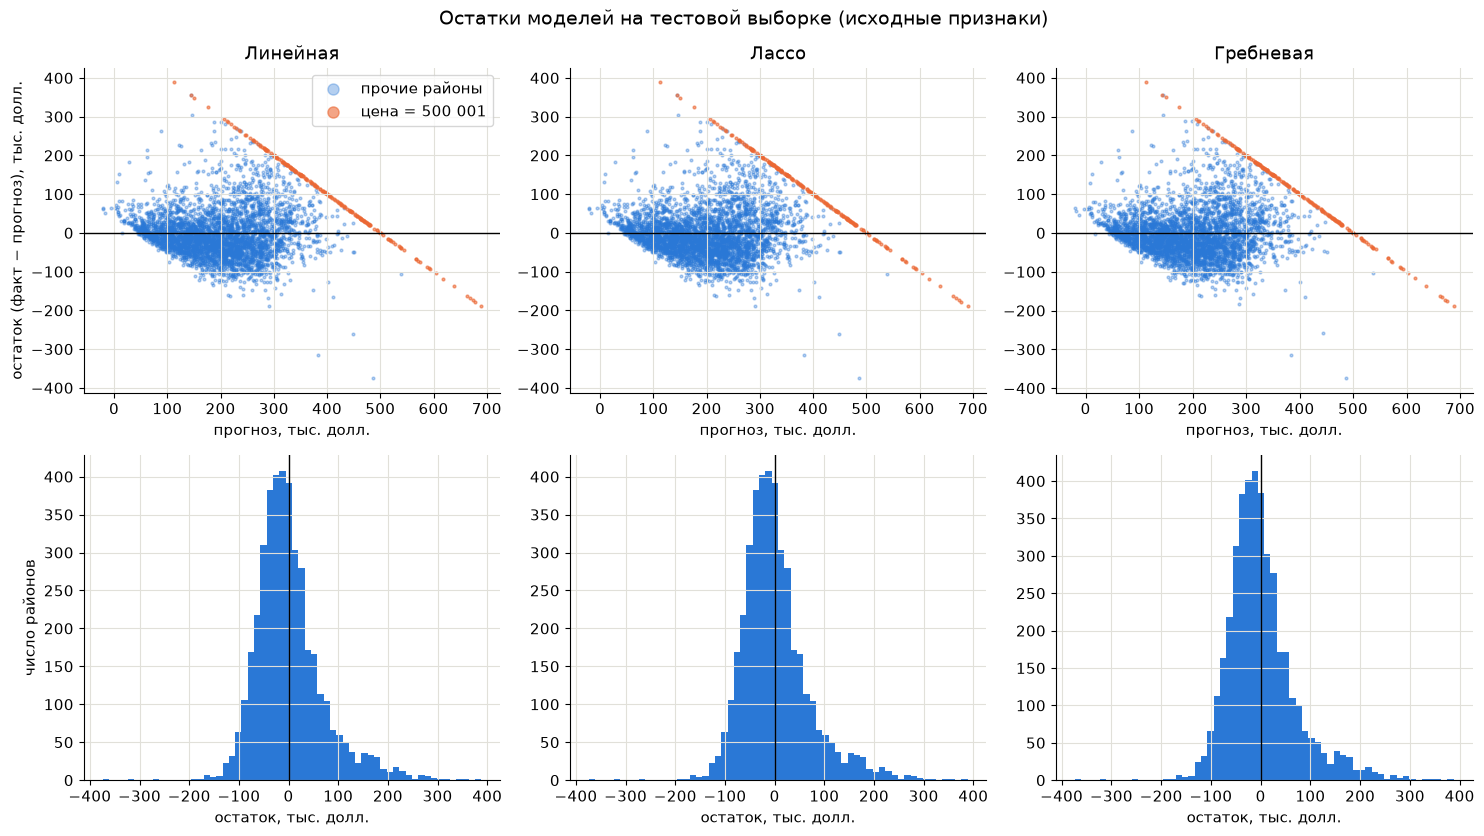

In [41]:
def plot_residuals(models, title, path):
    capped = (y_test == 500_001).to_numpy()
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    for j, (name, model) in enumerate(models.items()):
        y_pred = model.predict(X_test)
        resid = (y_test - y_pred).to_numpy()
        axes[0, j].scatter(y_pred[~capped] / 1000, resid[~capped] / 1000, s=4, alpha=0.35,
                           color=BLUE, label='прочие районы')
        axes[0, j].scatter(y_pred[capped] / 1000, resid[capped] / 1000, s=4, alpha=0.6,
                           color=ORANGE, label='цена = 500 001')
        axes[0, j].axhline(0, color='black', lw=1)
        axes[0, j].set_title(name)
        axes[0, j].set_xlabel('прогноз, тыс. долл.')
        axes[1, j].hist(resid / 1000, bins=60, color=BLUE)
        axes[1, j].axvline(0, color='black', lw=1)
        axes[1, j].set_xlabel('остаток, тыс. долл.')
    axes[0, 0].set_ylabel('остаток (факт − прогноз), тыс. долл.')
    axes[1, 0].set_ylabel('число районов')
    axes[0, 0].legend(markerscale=4)
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()

plot_residuals(models, 'Остатки моделей на тестовой выборке (исходные признаки)', 'Рисунки/10_остатки_исходные.png')

Графики остатков построены на тестовой выборке: по горизонтали — прогноз, по вертикали — остаток
$e = y - \hat y$, чёрная линия — уровень 0. У трёх моделей картина одинаковая, так как их коэффициенты почти
совпадают. Остатки не образуют равномерную горизонтальную полосу: при малых прогнозах разброс мал, с ростом
прогноза облако расширяется (форма «воронки»), то есть дисперсия остатков непостоянна — это гетероскедастичность.
Оранжевые точки — районы с ценой 500 001: у них одинаковый факт, поэтому они лежат на прямой
$e = 500\,001 - \hat y$ (наклонная «полоса»), при прогнозе ниже 500 тыс. остаток положительный, выше —
отрицательный. Нижняя граница облака слева тоже прямая: цена не бывает ниже 14 999 долл., поэтому остаток не может
быть меньше $14\,999 - \hat y$. Гистограммы остатков вытянуты вправо: крупные положительные остатки — сильно
недооценённые районы, среди них много районов со срезанной ценой (оранжевые точки в верхней части графика).

In [42]:
y_pred_lin = pipe_lin.predict(X_test)
resid_lin = y_test - y_pred_lin
spread = resid_lin.groupby(pd.qcut(y_pred_lin, 5), observed=True).std() / 1000
display(spread.round(1).to_frame('СКО остатков линейной модели, тыс. долл.'))
spread.round(6).to_frame('СКО остатков, тыс. долл.').to_csv('Результаты/разброс_остатков.csv', encoding='utf-8')
print('Отрицательных прогнозов на test:', (y_pred_lin < 0).sum(), '; минимальный прогноз:', round(y_pred_lin.min()))
print('Среднее остатков:', round(resid_lin.mean()), '; медиана:', round(resid_lin.median()))
print('Наибольший остаток:', round(resid_lin.max()), '; наименьший:', round(resid_lin.min()))

,"СКО остатков линейной модели, тыс. долл."
"(-21714.221, 126158.456]",42.5
"(126158.456, 179331.966]",51.9
"(179331.966, 224703.153]",67.2
"(224703.153, 276162.617]",78.8
"(276162.617, 690005.056]",83.8


Отрицательных прогнозов на test: 4 ; минимальный прогноз: -21714
Среднее остатков: 1573 ; медиана: -8644
Наибольший остаток: 388364 ; наименьший: -374538


Разброс остатков посчитан в пяти равных по численности группах тестовых районов, упорядоченных по прогнозу. СКО
остатков растёт с 42,5 тыс. долл. в группе самых низких прогнозов до 83,8 тыс. в группе самых высоких — почти
вдвое; это числовое подтверждение «воронки». Четыре прогноза отрицательны (минимальный −21 714 долл.): линейная
модель не ограничена снизу. Средний остаток на тесте 1 573 долл. (близок к нулю), а медиана −8 644 долл.: больше
чем у половины районов прогноз выше фактической цены, зато у части районов прогноз сильно занижен — наибольший
остаток +388 364 долл. (наименьший −374 538 долл.).

In [43]:
def bp_table(models):
    rows = []
    for name, model in models.items():
        for sample, X_s, y_s in [('train', X_train, y_train), ('test', X_test, y_test)]:
            resid = y_s - model.predict(X_s)
            exog = add_constant(model.named_steps['prep'].transform(X_s))
            lm, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(resid, exog)
            rows.append({'модель': name, 'выборка': sample, 'LM': lm, 'p-значение': lm_pvalue})
    return pd.DataFrame(rows).set_index(['модель', 'выборка'])

bp_base = bp_table(models)
bp_base.to_csv('Результаты/бп_исходные.csv', encoding='utf-8')
shown = bp_base.copy()
shown['p-значение'] = shown['p-значение'].map('{:.1e}'.format)
display(shown.round(1))

LM p-значение
модель    выборка                  
Линейная  train    714.2   4.1e-145
          test     310.7    2.6e-59
Лассо     train    714.2   4.1e-145
          test     310.7    2.6e-59
Гребневая train    716.9   1.1e-145
          test     325.0    2.7e-62

Тест Бреуша–Пагана проверяет гипотезу H₀: дисперсия остатков не зависит от признаков (гомоскедастичность).
Квадраты остатков регрессируются на признаки модели с константой; статистика LM = n·R² этой вспомогательной
регрессии при H₀ имеет распределение χ² с 12 степенями свободы (по числу признаков). В statsmodels по умолчанию
используется вариант теста, не требующий нормальности остатков (`robust=True`). Для линейной модели LM = 714,2 на
обучающей и 310,7 на тестовой выборке, p-значения 4,1·10⁻¹⁴⁵ и 2,6·10⁻⁵⁹ — гораздо меньше 0,05, гипотеза о
гомоскедастичности отвергается; для лассо и гребневой результат тот же. Вывод: остатки гетероскедастичны. Прогнозы
при этом строить можно, но точность неодинакова: у дорогих районов ошибка больше общей RMSE, у дешёвых — меньше;
кроме того, стандартные ошибки коэффициентов, рассчитанные по обычным формулам МНК, были бы недостоверны.

## 7. Метод главных компонент
### 7.1. Стандартизация перед PCA

In [44]:
scaler_pca = StandardScaler().fit(X_train[num_features])
Z_train = scaler_pca.transform(X_train[num_features])
Z_test = scaler_pca.transform(X_test[num_features])
print('Средние Z_train:', Z_train.mean(axis=0).round(3))
print('СКО Z_train:   ', Z_train.std(axis=0).round(3))

Средние Z_train: [-0.  0. -0.  0. -0.  0. -0. -0.]
СКО Z_train:    [1. 1. 1. 1. 1. 1. 1. 1.]


Перед PCA выполнена стандартизация восьми числовых признаков: `StandardScaler` обучается (`fit`) только на
обучающей выборке, затем методом `transform` с теми же параметрами преобразуются и обучающая, и тестовая выборки.
После стандартизации у каждого признака среднее 0 и СКО 1. Без неё PCA раскладывал бы ковариационную матрицу
исходных признаков, и первые компоненты определялись бы признаками с наибольшей дисперсией (`total_rooms`,
`population` — дисперсии порядка 10⁶), а не связями между признаками; после стандартизации раскладывается
корреляционная матрица. Категориальный признак в PCA не включается: по лекции метод работает только с
непрерывными данными, поэтому фиктивные признаки `ocean_proximity` передаются в модель без изменений.

### 7.2. Собственные значения и доли объяснённой дисперсии

In [45]:
pca_full = PCA().fit(Z_train)
eigenvalues = pca_full.explained_variance_
cum_share = np.cumsum(pca_full.explained_variance_ratio_) * 100
variance = pd.DataFrame({'собственное значение': eigenvalues,
                         'доля дисперсии, %': pca_full.explained_variance_ratio_ * 100,
                         'накопленная доля, %': cum_share},
                        index=[f'PC{i}' for i in range(1, len(eigenvalues) + 1)])
display(variance.round(3))
variance.round(6).to_csv('Результаты/pca_дисперсия.csv', encoding='utf-8')
print('Сумма собственных значений:', round(eigenvalues.sum(), 4))

,собственное значение,"доля дисперсии, %","накопленная доля, %"
PC1,3.896,48.696,48.696
PC2,1.907,23.837,72.532
PC3,1.069,13.368,85.900
PC4,0.826,10.325,96.225
PC5,0.157,1.958,98.184
PC6,0.083,1.032,99.216
PC7,0.047,0.592,99.808
PC8,0.015,0.192,100.000


Сумма собственных значений: 8.0005


PCA обучен на стандартизованной обучающей выборке без ограничения числа компонент, чтобы получить все 8 собственных
значений. Собственное значение λ — дисперсия данных вдоль главной компоненты; доля объяснённой дисперсии
`explained_variance_ratio_` = λ / (сумма всех λ). Накопленная доля — сумма долей первых k компонент
(`np.cumsum`). Сумма собственных значений 8,0005 ≈ 8 — суммарная дисперсия восьми стандартизованных признаков
(отличие в четвёртом знаке: PCA делит на n − 1, а `StandardScaler` — на n). Первая компонента объясняет 48,70 %
дисперсии, вторая — 23,84 %, третья — 13,37 %, четвёртая — 10,33 %; вместе четыре компоненты — 96,23 %, на
последние четыре приходится менее 4 %.

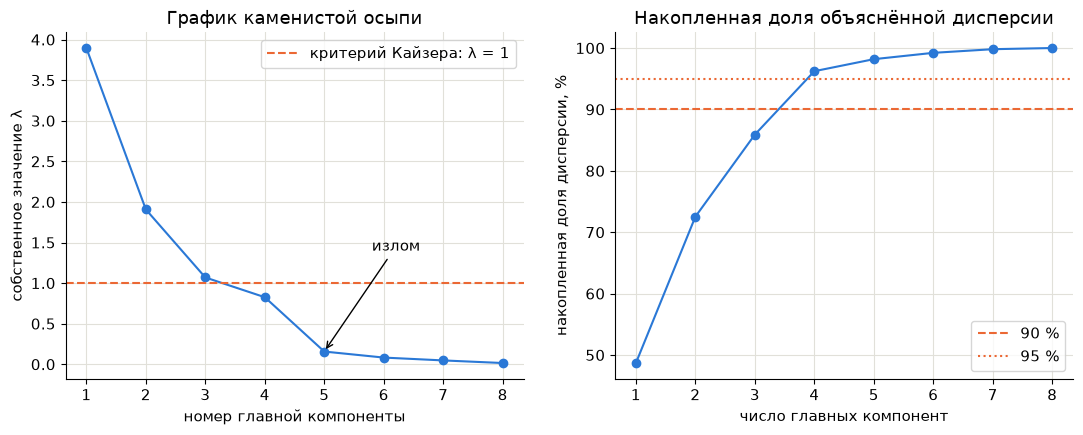

In [46]:
k_range = np.arange(1, len(eigenvalues) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(k_range, eigenvalues, marker='o', color=BLUE)
axes[0].axhline(1, color=ORANGE, ls='--', label='критерий Кайзера: λ = 1')
axes[0].annotate('излом', xy=(5, eigenvalues[4]), xytext=(5.8, 1.4),
                 arrowprops={'arrowstyle': '->', 'color': 'black'})
axes[0].set_xlabel('номер главной компоненты')
axes[0].set_ylabel('собственное значение λ')
axes[0].set_title('График каменистой осыпи')
axes[0].legend()
axes[1].plot(k_range, cum_share, marker='o', color=BLUE)
axes[1].axhline(90, color=ORANGE, ls='--', label='90 %')
axes[1].axhline(95, color=ORANGE, ls=':', label='95 %')
axes[1].set_xlabel('число главных компонент')
axes[1].set_ylabel('накопленная доля дисперсии, %')
axes[1].set_title('Накопленная доля объяснённой дисперсии')
axes[1].legend(loc='lower right')
fig.savefig('Рисунки/11_каменистая_осыпь.png', dpi=200, bbox_inches='tight')
plt.show()

Слева — график каменистой осыпи: собственные значения по номерам компонент. На первых четырёх компонентах
собственное значение снижается от 3,90 до 0,83, затем резко падает до 0,16 на пятой и дальше почти не меняется
(0,08; 0,05; 0,02) — это «осыпь» из малозначимых компонент. Излом приходится на пятую компоненту, поэтому
оставляются компоненты до него, то есть четыре. Справа — накопленная доля: порог 90 % впервые превышен при
4 компонентах (96,2 %), при 4 же превышен и порог 95 %.

### 7.3. Выбор числа компонент

In [47]:
criteria = pd.Series({
    'Кайзер: λ > 1': int((eigenvalues > 1).sum()),
    'Джоллифф: λ > 0,7': int((eigenvalues > 0.7).sum()),
    'накопленная доля ≥ 80 %': int(np.argmax(cum_share >= 80) + 1),
    'накопленная доля ≥ 90 %': int(np.argmax(cum_share >= 90) + 1),
    'накопленная доля ≥ 95 %': int(np.argmax(cum_share >= 95) + 1),
}, name='компонент')
display(criteria.to_frame())
criteria.to_csv('Результаты/pca_критерии.csv', encoding='utf-8')

loadings_full = pca_full.components_.T * np.sqrt(eigenvalues)
communality = pd.DataFrame({'3 компоненты': (loadings_full[:, :3] ** 2).sum(axis=1),
                            '4 компоненты': (loadings_full[:, :4] ** 2).sum(axis=1)}, index=num_features)
display(communality.round(3))
communality.round(6).to_csv('Результаты/pca_общности.csv', encoding='utf-8')

N_COMPONENTS = int(np.argmax(cum_share >= 90) + 1)
print('Выбрано главных компонент:', N_COMPONENTS)

,компонент
Кайзер: λ > 1,3
"Джоллифф: λ > 0,7",4
накопленная доля ≥ 80 %,3
накопленная доля ≥ 90 %,4
накопленная доля ≥ 95 %,4


,3 компоненты,4 компоненты
longitude,0.965,0.968
latitude,0.960,0.969
housing_median_age,0.344,0.999
total_rooms,0.933,0.944
total_bedrooms,0.960,0.964
population,0.879,0.885
households,0.964,0.972
median_income,0.867,0.998


Выбрано главных компонент: 4


Число компонент выбирается по доле объяснённой дисперсии, с проверкой по графику осыпи и другим критериям. Критерий
Кайзера (оставлять компоненты с λ > 1, то есть объясняющие больше дисперсии, чем один стандартизованный признак)
даёт 3, так как λ₄ = 0,83 < 1; порог 80 % (нижняя граница диапазона 80–90 % из лекции) — тоже 3 (85,9 %); пороги
90 % и 95 % — 4; более мягкий порог λ > 0,7, который Джоллифф предлагает для корреляционной матрицы, — 4. Выбор
между 3 и 4 решает таблица общностей — доля дисперсии каждого признака, объяснённая оставленными компонентами
(сумма квадратов нагрузок): при 3 компонентах `housing_median_age` объясняется только на 34,4 %, при 4 — на 99,9 %;
у `median_income` — 86,7 % и 99,8 %. Значит, четвёртая компонента несёт почти всю информацию о возрасте домов.
Выбрано **4 компоненты**: это наименьшее число компонент, объясняющих не меньше 90 % дисперсии (так оно и
вычисляется в коде), и оно совпадает с изломом на графике осыпи.

### 7.4. Нагрузки главных компонент

,PC1,PC2,PC3,PC4
longitude,0.077,0.702,-0.049,-0.064
latitude,-0.074,-0.702,0.004,-0.104
housing_median_age,-0.218,-0.018,-0.385,0.890
total_rooms,0.484,-0.077,0.093,0.113
total_bedrooms,0.491,-0.060,-0.117,0.064
population,0.471,-0.027,-0.115,0.084
households,0.492,-0.063,-0.109,0.097
median_income,0.045,0.023,0.896,0.399


,PC1,PC2,PC3,PC4
longitude,0.151,0.969,-0.050,-0.059
latitude,-0.147,-0.969,0.005,-0.095
housing_median_age,-0.430,-0.025,-0.398,0.809
total_rooms,0.955,-0.107,0.096,0.103
total_bedrooms,0.969,-0.083,-0.121,0.058
population,0.929,-0.038,-0.119,0.076
households,0.971,-0.087,-0.112,0.088
median_income,0.088,0.032,0.926,0.362


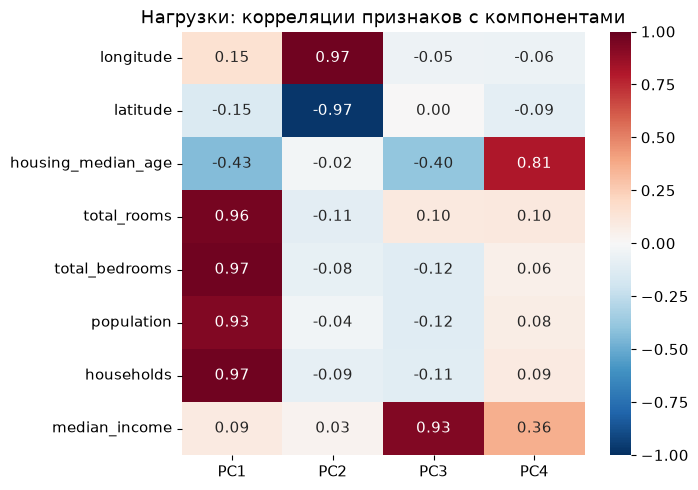

In [48]:
pca = PCA(n_components=N_COMPONENTS).fit(Z_train)
pc_names = [f'PC{i}' for i in range(1, N_COMPONENTS + 1)]
weights = pd.DataFrame(pca.components_.T, index=num_features, columns=pc_names)
loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_), index=num_features, columns=pc_names)
display(weights.round(3))
display(loadings.round(3))
weights.round(6).to_csv('Результаты/pca_веса.csv', encoding='utf-8')
loadings.round(6).to_csv('Результаты/pca_нагрузки.csv', encoding='utf-8')

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax)
ax.grid(False)
ax.set_title('Нагрузки: корреляции признаков с компонентами')
fig.savefig('Рисунки/12_нагрузки.png', dpi=200, bbox_inches='tight')
plt.show()

Первая таблица — веса компонент `pca.components_` (собственные векторы: коэффициенты, с которыми стандартизованные
признаки входят в компоненту). Вторая таблица и тепловая карта — нагрузки: вес × √λ, для стандартизованных данных
это корреляции признаков с компонентами. Интерпретация компонент:

- **PC1 (48,7 %) — размер района**: высокие нагрузки у `total_rooms` (0,96), `total_bedrooms` (0,97), `population`
  (0,93), `households` (0,97) и отрицательная у возраста домов (−0,43) — в больших районах дома в среднем новее
  (корреляция возраста с `total_rooms` −0,36).
- **PC2 (23,8 %) — местоположение**: `longitude` 0,97 и `latitude` −0,97; большие значения PC2 у районов на
  юго-востоке штата, малые — на северо-западе.
- **PC3 (13,4 %) — доход**: `median_income` 0,93, возраст домов −0,40.
- **PC4 (10,3 %) — возраст застройки**: `housing_median_age` 0,81, доход 0,36.

Знак компоненты определён с точностью до умножения на −1: если поменять знаки всех нагрузок компоненты, её смысл
не изменится.

### 7.5. Преобразование выборок и размеры матриц

In [49]:
PC_train = pca.transform(Z_train)
PC_test = pca.transform(Z_test)
n_dummies = X_train_prep.shape[1] - len(num_features)
print('Числовые признаки до PCA:  train', Z_train.shape, ' test', Z_test.shape)
print('Главные компоненты:        train', PC_train.shape, ' test', PC_test.shape)
print('Вся матрица признаков модели: до PCA', X_train_prep.shape,
      ' после PCA', (PC_train.shape[0], PC_train.shape[1] + n_dummies))

Числовые признаки до PCA:  train (16344, 8)  test (4086, 8)
Главные компоненты:        train (16344, 4)  test (4086, 4)
Вся матрица признаков модели: до PCA (16344, 12)  после PCA (16344, 8)


Тестовая выборка переводится в главные компоненты без повторного обучения: сначала `scaler_pca.transform` (средние
и СКО обучающей выборки), затем `pca.transform` (собственные векторы, найденные на обучающей выборке). Числовая
часть данных сжата с 16 344 × 8 и 4 086 × 8 до 16 344 × 4 и 4 086 × 4; вся матрица признаков модели вместе с
четырьмя фиктивными признаками уменьшилась с 12 до 8 столбцов.

### 7.6. Проверка устранения мультиколлинеарности

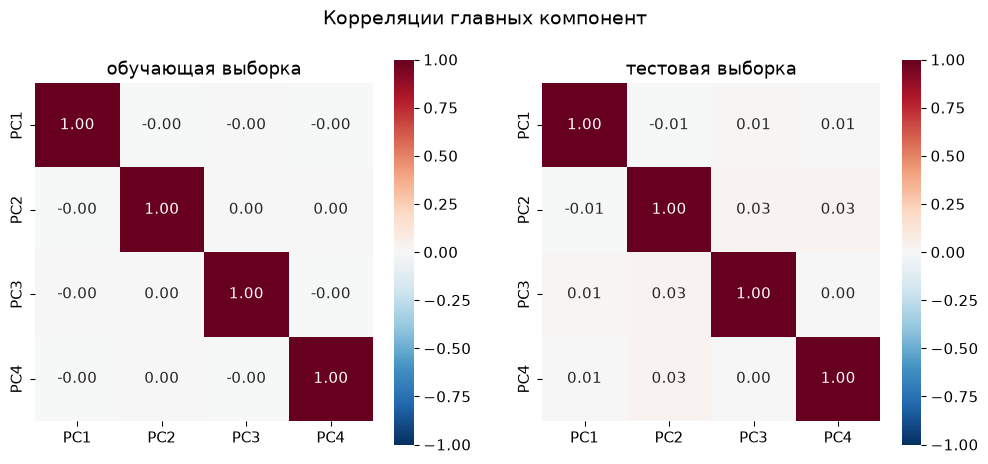

,VIF (компоненты),VIF (компоненты + dummy)
PC1,1.0,1.012
PC2,1.0,1.403
PC3,1.0,1.016
PC4,1.0,1.210
ocean_proximity_INLAND,NaN,1.496
ocean_proximity_ISLAND,NaN,1.001
ocean_proximity_NEAR BAY,NaN,1.550
ocean_proximity_NEAR OCEAN,NaN,1.132


Наибольшая по модулю корреляция компонент на test: 0.031


In [50]:
pc_train_df = pd.DataFrame(PC_train, columns=pc_names)
pc_test_df = pd.DataFrame(PC_test, columns=pc_names)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in [(axes[0], pc_train_df, 'обучающая выборка'), (axes[1], pc_test_df, 'тестовая выборка')]:
    sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=ax)
    ax.grid(False)
    ax.set_title(title)
fig.suptitle('Корреляции главных компонент', fontsize=14)
fig.savefig('Рисунки/13_корреляции_компонент.png', dpi=200, bbox_inches='tight')
plt.show()

dummies = X_train_prep.drop(columns=num_features).reset_index(drop=True)
vif_pca = pd.DataFrame({'VIF (компоненты)': vif_table(pc_train_df),
                        'VIF (компоненты + dummy)': vif_table(pd.concat([pc_train_df, dummies], axis=1))})
display(vif_pca.round(3))
vif_pca.round(6).to_csv('Результаты/vif_pca.csv', encoding='utf-8')
off_diag = pc_test_df.corr().where(~np.eye(N_COMPONENTS, dtype=bool)).abs().max().max()
print('Наибольшая по модулю корреляция компонент на test:', round(off_diag, 3))

Проверка устранения мультиколлинеарности. На обучающей выборке корреляции между компонентами равны нулю (значения
−0,00 — округлённые машинные нули порядка 10⁻¹⁶): главные компоненты ортогональны по построению. На тестовой
выборке корреляции не строго нулевые, так как компоненты построены по обучающей, но малы — наибольшая по модулю
0,031. VIF всех компонент равен 1,0 (у исходных признаков был до 35,00), а вместе с фиктивными признаками
`ocean_proximity` VIF не превышает 1,55. Мультиколлинеарность устранена.

## 8. Регрессия на главных компонентах
### 8.1. Модели в Pipeline с PCA

In [51]:
def make_pca_preprocessor(n_components):
    num_pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=n_components))])
    return ColumnTransformer([
        ('num', num_pipe, num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features),
    ], verbose_feature_names_out=False)

pipe_lin_pca = Pipeline([('prep', make_pca_preprocessor(N_COMPONENTS)), ('model', LinearRegression())])
pipe_lin_pca.fit(X_train, y_train)
pipe_lin_pca

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix an

Модели на главных компонентах собраны в такой же `Pipeline`, но шаг предобработки другой: для числовых признаков —
вложенный конвейер `StandardScaler` → `PCA(n_components=4)`, для `ocean_proximity` — тот же `OneHotEncoder`.
Порядок шагов: стандартизация (обязательна перед PCA) → PCA → модель. Так как стандартизация и PCA находятся
внутри конвейера, при кросс-валидации и подборе alpha они обучаются заново на обучающих фолдах каждого разбиения,
а к проверочному фолду только применяются.

In [52]:
grid_lasso_pca = GridSearchCV(Pipeline([('prep', make_pca_preprocessor(N_COMPONENTS)), ('model', Lasso())]),
                              param_grid={'model__alpha': alphas}, cv=cv,
                              scoring='neg_root_mean_squared_error').fit(X_train, y_train)
grid_ridge_pca = GridSearchCV(Pipeline([('prep', make_pca_preprocessor(N_COMPONENTS)), ('model', Ridge())]),
                              param_grid={'model__alpha': alphas}, cv=cv,
                              scoring='neg_root_mean_squared_error').fit(X_train, y_train)
for name, grid in [('Лассо', grid_lasso_pca), ('Гребневая', grid_ridge_pca)]:
    print(f'{name} на главных компонентах: лучшее alpha = {grid.best_params_["model__alpha"]}, '
          f'RMSE на кросс-валидации = {-grid.best_score_:.1f}')

Лассо на главных компонентах: лучшее alpha = 0.01, RMSE на кросс-валидации = 72781.6
Гребневая на главных компонентах: лучшее alpha = 0.01, RMSE на кросс-валидации = 72781.7


Подбор alpha для лассо и гребневой регрессии на главных компонентах выполнен по той же сетке из 29 значений, на тех
же фолдах `cv` и по той же метрике. Для обеих моделей лучшим оказалось наименьшее значение alpha = 0,01, RMSE на
кросс-валидации 72 781,6 и 72 781,7 долл. Регуляризация и здесь не улучшает модель: после PCA признаки
некоррелированы (VIF ≈ 1), и мультиколлинеарности, с которой помогает бороться гребневая регрессия, уже нет.

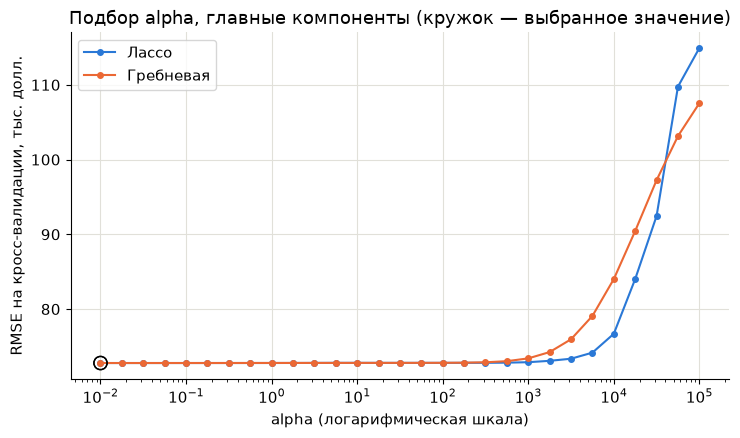

In [53]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for grid, name, color in [(grid_lasso_pca, 'Лассо', BLUE), (grid_ridge_pca, 'Гребневая', ORANGE)]:
    ax.plot(alphas, -grid.cv_results_['mean_test_score'] / 1000, marker='o', markersize=4,
            color=color, label=name)
    ax.scatter(grid.best_params_['model__alpha'], -grid.best_score_ / 1000, s=90,
               facecolor='none', edgecolor='black', zorder=3)
ax.set_xscale('log')
ax.set_xlabel('alpha (логарифмическая шкала)')
ax.set_ylabel('RMSE на кросс-валидации, тыс. долл.')
ax.set_title('Подбор alpha, главные компоненты (кружок — выбранное значение)')
ax.legend()
fig.savefig('Рисунки/14_подбор_alpha_PCA.png', dpi=200, bbox_inches='tight')
plt.show()

Кривые RMSE(alpha) на главных компонентах повторяют картину раздела 5: почти горизонтальный участок при малых
alpha и рост ошибки при больших. Но весь график выше: минимальная RMSE около 72,8 тыс. долл. против 69,0 тыс. на
исходных признаках.

In [54]:
check = cross_validate(pipe_lin_pca, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error',
                       return_estimator=True)
rows = []
for i, est in enumerate(check['estimator'], 1):
    num_pipe = est.named_steps['prep'].named_transformers_['num']
    print(f'фолд {i}: среднее median_income в scaler = {num_pipe.named_steps["scaler"].mean_[-1]:.4f}, '
          f'доля дисперсии PC1 = {num_pipe.named_steps["pca"].explained_variance_ratio_[0]:.4f}')
    rows.append({'фолд': i, 'среднее median_income': num_pipe.named_steps['scaler'].mean_[-1],
                 'доля дисперсии PC1': num_pipe.named_steps['pca'].explained_variance_ratio_[0]})
pd.DataFrame(rows).round(6).to_csv('Результаты/фолды_pca.csv', index=False, encoding='utf-8')

фолд 1: среднее median_income в scaler = 3.8743, доля дисперсии PC1 = 0.4881
фолд 2: среднее median_income в scaler = 3.8661, доля дисперсии PC1 = 0.4882
фолд 3: среднее median_income в scaler = 3.8747, доля дисперсии PC1 = 0.4856
фолд 4: среднее median_income в scaler = 3.8707, доля дисперсии PC1 = 0.4875
фолд 5: среднее median_income в scaler = 3.8662, доля дисперсии PC1 = 0.4857


Проверка того, что стандартизация и PCA обучаются заново в каждом разбиении: `cross_validate(...,
return_estimator=True)` возвращает пять обученных конвейеров. Среднее `median_income`, запомненное стандартизатором,
в фолдах разное (от 3,8661 до 3,8747), разная и доля дисперсии первой компоненты (от 0,4856 до 0,4882): каждый фолд
использует свои параметры, вычисленные без проверочной части.

In [55]:
models_pca = {'Линейная': pipe_lin_pca, 'Лассо': grid_lasso_pca.best_estimator_,
              'Гребневая': grid_ridge_pca.best_estimator_}
cv_pca = cv_table(models_pca)
display(cv_pca.round(4))
cv_pca.round(6).to_csv('Результаты/cv_pca.csv', encoding='utf-8')

,RMSE,RMSE ±,R2,R2 ±,"MAPE, %","MAPE ±, %"
Линейная,72781.6057,1608.6926,0.5989,0.0063,29.9543,0.751
Лассо,72781.6442,1608.7506,0.5989,0.0063,29.9544,0.751
Гребневая,72781.7460,1609.0354,0.5989,0.0063,29.9544,0.751


Метрики кросс-валидации на главных компонентах: RMSE = 72 782 ± 1 609 долл., R² = 0,599 ± 0,006,
MAPE = 29,95 ± 0,75 % — у трёх моделей одинаково. По сравнению с исходными признаками RMSE выросла на 3 805 долл.
(5,5 %), R² снизился с 0,640 до 0,599.

In [56]:
coef_pca = pd.DataFrame({name: model.named_steps['model'].coef_ for name, model in models_pca.items()},
                        index=pipe_lin_pca.named_steps['prep'].get_feature_names_out())
coef_pca.loc['свободный член'] = [model.named_steps['model'].intercept_ for model in models_pca.values()]
display(coef_pca.round(1))
coef_pca.round(6).to_csv('Результаты/коэффициенты_pca.csv', encoding='utf-8')

,Линейная,Лассо,Гребневая
pca0,3755.3,3755.3,3755.3
pca1,-1083.6,-1083.6,-1083.5
pca2,58824.9,58824.9,58824.8
pca3,42585.3,42585.4,42585.4
ocean_proximity_INLAND,-71480.3,-71480.3,-71480.2
ocean_proximity_ISLAND,168402.5,168361.6,167982.2
ocean_proximity_NEAR BAY,5436.1,5435.9,5436.0
ocean_proximity_NEAR OCEAN,16453.0,16452.9,16452.8
свободный член,226405.3,226405.4,226405.5


Коэффициенты моделей на компонентах (`pca0`–`pca3` — это PC1–PC4, долл. на единицу компоненты). Наибольшие
коэффициенты у PC3 «доход» (+58 825) и PC4 «возраст застройки» (+42 585), у PC1 «размер района» и PC2
«местоположение» — малые (+3 755 и −1 084). Заметно вырос по модулю коэффициент `INLAND`: −71 480 долл. против
−39 120 до PCA — часть сведений о местоположении, которую модель раньше брала из координат, теперь передаёт
категория (почему так получилось, видно по весам отброшенных компонент в разделе 8.2). Коэффициенты трёх моделей
практически совпадают.

### 8.2. Сравнение моделей до и после PCA

In [57]:
rows = []
for stage, model_set, cv_res in [('до PCA', models, cv_base), ('после PCA', models_pca, cv_pca)]:
    for name, model in model_set.items():
        rows.append({'модель': name, 'признаки': stage, **regression_metrics(y_test, model.predict(X_test)),
                     'RMSE CV': cv_res.loc[name, 'RMSE']})
comparison = pd.DataFrame(rows).set_index(['модель', 'признаки'])
display(comparison.round(4))
comparison.round(6).to_csv('Результаты/сравнение_до_после_pca.csv', encoding='utf-8')

before = comparison.xs('до PCA', level='признаки')
after = comparison.xs('после PCA', level='признаки')
display(((after - before) / before * 100).round(2).add_suffix(': изменение, %'))

,,RMSE,R2,"MAPE, %",MAE,RMSE CV
модель,признаки,,,,,
Линейная,до PCA,68157.3296,0.6630,28.1829,49481.7845,68976.3340
Лассо,до PCA,68157.3443,0.6630,28.1829,49481.7974,68976.3746
Гребневая,до PCA,68253.4120,0.6621,28.1614,49514.3866,68969.9315
Линейная,после PCA,72893.6696,0.6146,29.6448,52867.0595,72781.6057
Лассо,после PCA,72893.6805,0.6146,29.6448,52867.0748,72781.6442
Гребневая,после PCA,72893.7765,0.6146,29.6448,52867.1941,72781.7460


,"RMSE: изменение, %","R2: изменение, %","MAPE, %: изменение, %","MAE: изменение, %","RMSE CV: изменение, %"
модель,,,,,
Линейная,6.95,-7.31,5.19,6.84,5.52
Лассо,6.95,-7.31,5.19,6.84,5.52
Гребневая,6.80,-7.18,5.27,6.77,5.53


Итоговая таблица сравнивает модели на одной и той же тестовой выборке (4 086 районов) по одним и тем же метрикам
(функция `regression_metrics`); для всех моделей использованы одни и те же фолды `cv` и сетка alpha. После PCA
все три модели стали хуже: RMSE выросла с 68 157 до 72 894 долл. (+6,95 %) у линейной и лассо и с 68 253 до
72 894 долл. (+6,80 %) у гребневой; R² снизился с 0,663 (0,662) до 0,615; MAPE выросла с 28,18 (28,16) до 29,64 %,
MAE — с 49 482 (49 514) до 52 867 долл. На кросс-валидации RMSE выросла на 5,5 %. Ни для одной модели PCA
результат не улучшил. Четыре компоненты сохраняют 96,2 % дисперсии признаков, но в отброшенных 3,8 % оказались
сочетания признаков, важные для цены (это показано ниже).

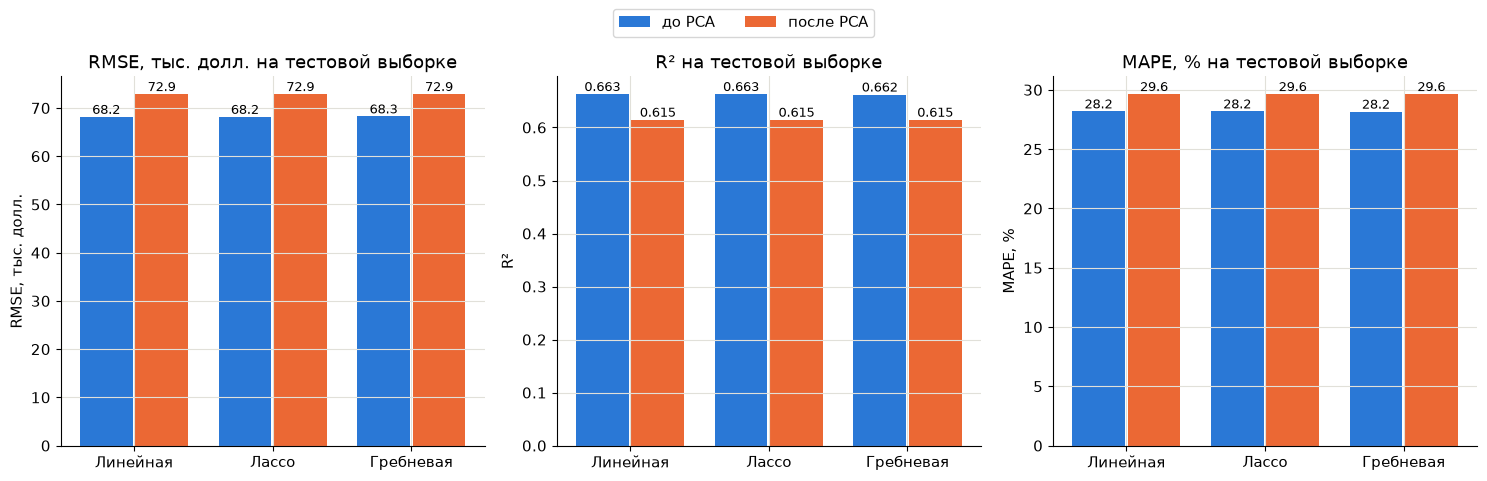

In [58]:
names = list(models)
x = np.arange(len(names))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, divider, label, fmt in [(axes[0], 'RMSE', 1000, 'RMSE, тыс. долл.', '%.1f'),
                                        (axes[1], 'R2', 1, 'R²', '%.3f'),
                                        (axes[2], 'MAPE, %', 1, 'MAPE, %', '%.1f')]:
    bars_before = ax.bar(x - 0.2, before.loc[names, metric] / divider, width=0.38, color=BLUE, label='до PCA')
    bars_after = ax.bar(x + 0.2, after.loc[names, metric] / divider, width=0.38, color=ORANGE, label='после PCA')
    ax.bar_label(bars_before, fmt=fmt, fontsize=9)
    ax.bar_label(bars_after, fmt=fmt, fontsize=9)
    ax.set_xticks(x, names)
    ax.set_ylabel(label)
    ax.set_title(label + ' на тестовой выборке')
fig.legend(handles=[bars_before, bars_after], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
fig.savefig('Рисунки/15_сравнение_до_после_PCA.png', dpi=200, bbox_inches='tight')
plt.show()

Столбчатые диаграммы показывают то же: у всех трёх моделей оранжевые столбцы (после PCA) выше синих по RMSE и MAPE
и ниже по R². Различий между тремя моделями внутри одной группы признаков на графике не видно — регуляризация на
результат почти не влияет.

,"накопленная доля, %",RMSE CV,R2 CV
компонент,,,
1,48.6956,100254.5779,0.2389
2,72.5324,100189.8787,0.2398
3,85.9000,80828.3736,0.5053
4,96.2254,72781.6057,0.5989
5,98.1839,71056.8451,0.6177
6,99.2156,69084.3249,0.6386
7,99.8081,68980.6018,0.6397
8,100.0000,68976.3340,0.6398


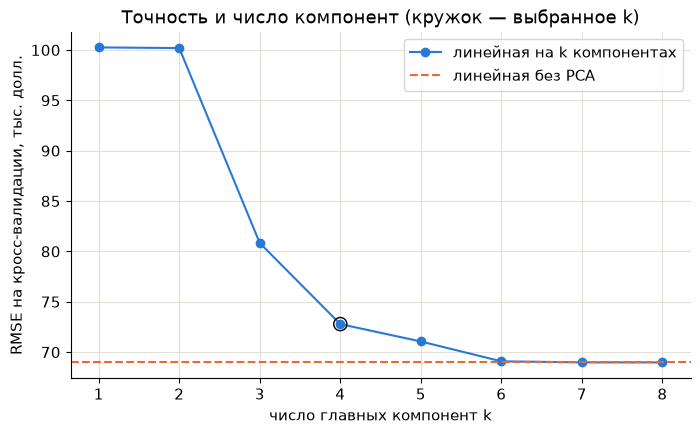

In [59]:
rows = []
for k in k_range:
    pipe_k = Pipeline([('prep', make_pca_preprocessor(k)), ('model', LinearRegression())])
    s = cross_validate(pipe_k, X_train, y_train, cv=cv, scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'})
    rows.append({'компонент': k, 'накопленная доля, %': cum_share[k - 1],
                 'RMSE CV': -s['test_rmse'].mean(), 'R2 CV': s['test_r2'].mean()})
k_curve = pd.DataFrame(rows).set_index('компонент')
display(k_curve.round(4))
k_curve.round(6).to_csv('Результаты/число_компонент.csv', encoding='utf-8')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_curve.index, k_curve['RMSE CV'] / 1000, marker='o', color=BLUE, label='линейная на k компонентах')
ax.axhline(cv_base.loc['Линейная', 'RMSE'] / 1000, color=ORANGE, ls='--', label='линейная без PCA')
ax.scatter(N_COMPONENTS, k_curve.loc[N_COMPONENTS, 'RMSE CV'] / 1000, s=90, facecolor='none',
           edgecolor='black', zorder=3)
ax.set_xlabel('число главных компонент k')
ax.set_ylabel('RMSE на кросс-валидации, тыс. долл.')
ax.set_title('Точность и число компонент (кружок — выбранное k)')
ax.legend()
fig.savefig('Рисунки/16_число_компонент.png', dpi=200, bbox_inches='tight')
plt.show()

Чтобы понять причину ухудшения, линейная регрессия обучена на k = 1…8 компонентах (5-кратная кросс-валидация на
обучающей выборке). При k = 1–2 RMSE около 100 тыс. долл. (R² ≈ 0,24), при k = 3 — 80 828 (R² = 0,505), при
выбранном k = 4 — 72 782 (R² = 0,599), при k = 5 — 71 057, при k = 6 — 69 084 (R² = 0,639), при k = 8 — 68 976, ровно
как без PCA: 8 компонент — это только поворот осей, и линейная модель на них даёт те же прогнозы. Пятая и шестая
компоненты объясняют всего 1,96 % и 1,03 % дисперсии признаков, но заметно снижают ошибку. PCA выбирает
направления по дисперсии признаков и не учитывает цель, поэтому малая доля дисперсии не означает малую пользу для
прогноза. Для прогноза лучше подошли бы 6 компонент (99,2 % дисперсии): RMSE всего на 108 долл. больше, чем без
PCA, и мультиколлинеарности нет.

In [60]:
discarded = pd.DataFrame(pca_full.components_[N_COMPONENTS:].T, index=num_features,
                         columns=[f'PC{i}' for i in range(N_COMPONENTS + 1, len(eigenvalues) + 1)])
display(discarded.round(3))
discarded.round(6).to_csv('Результаты/pca_веса_отброшенных.csv', encoding='utf-8')

,PC5,PC6,PC7,PC8
longitude,-0.090,0.470,-0.514,-0.051
latitude,-0.041,0.454,-0.531,-0.037
housing_median_age,-0.034,0.091,-0.043,0.003
total_rooms,-0.314,0.572,0.537,-0.158
total_bedrooms,-0.378,-0.226,-0.216,0.705
population,0.851,0.121,-0.018,0.132
households,-0.142,-0.411,-0.298,-0.674
median_income,0.056,-0.061,-0.167,0.043


Веса отброшенных компонент объясняют потерю точности. PC5 (1,96 % дисперсии) противопоставляет население (вес
0,851) комнатам и спальням (−0,314 и −0,378), то есть описывает, насколько плотно заселено жильё. PC6 (1,03 %)
содержит сумму долготы и широты (0,470 и 0,454) и противопоставление комнат и домохозяйств (0,572 и −0,411).
Модель на исходных признаках использовала именно такие сочетания: коэффициенты долготы и широты почти равны и оба
отрицательны (−52 950 и −53 628), то есть прогноз снижается при одновременном росте обеих координат — при движении
на северо-восток, вглубь штата (побережье на карте вытянуто с северо-запада на юго-восток); у `population` и
`total_bedrooms` коэффициенты противоположных знаков (−40 333 и +42 827). При k = 4 эти направления отброшены,
поэтому ошибка выросла, а часть сведений о местоположении перешла к фиктивному признаку `INLAND` (его коэффициент
вырос по модулю с 39 120 до 71 480 долл.).

### 8.3. Остатки моделей на главных компонентах

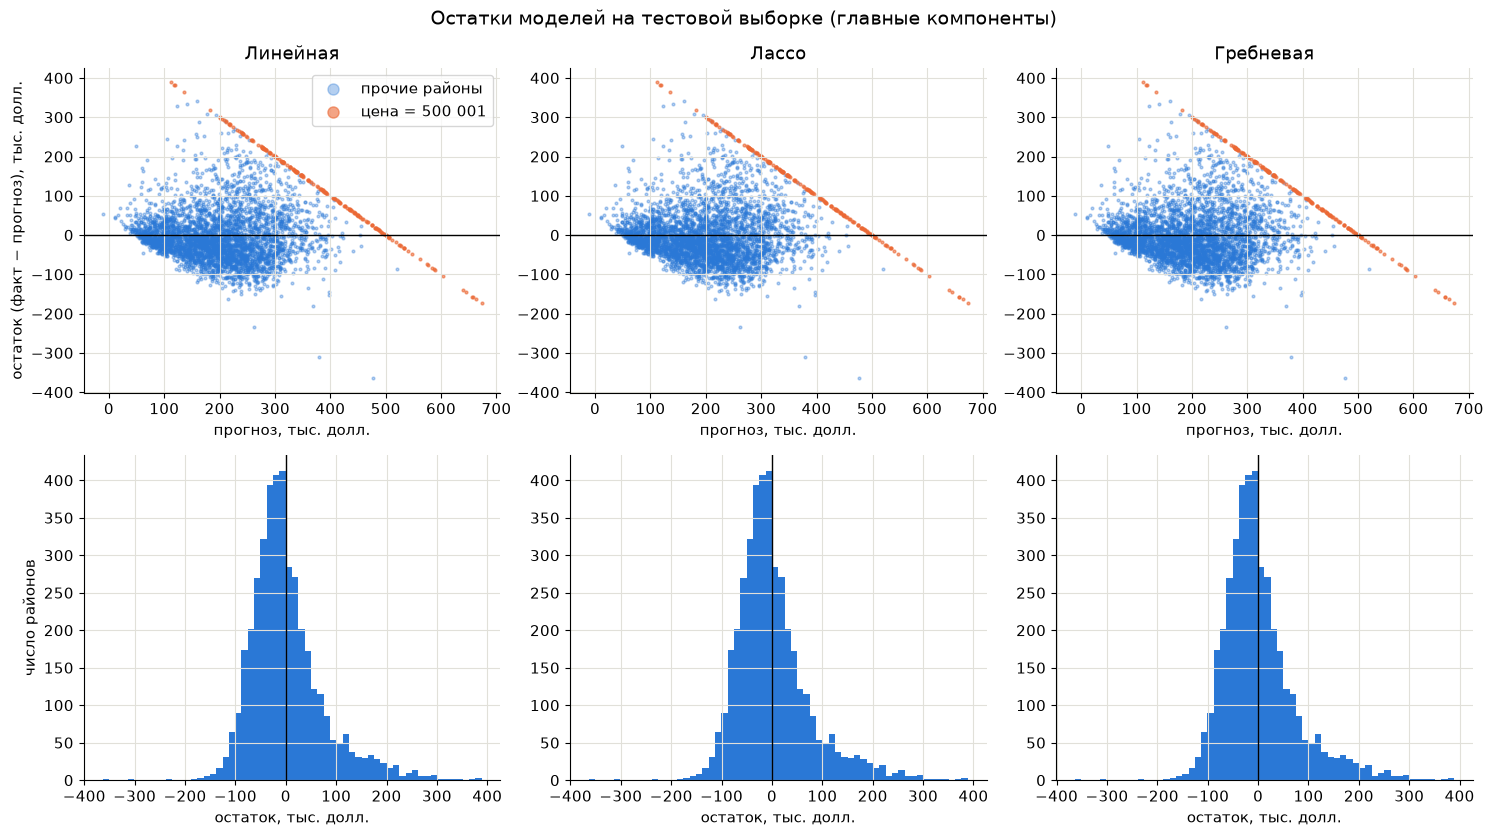

LM p-значение
модель    выборка                  
Линейная  train    590.3   2.8e-122
          test     181.2    5.8e-35
Лассо     train    590.3   2.8e-122
          test     181.2    5.8e-35
Гребневая train    590.3   2.8e-122
          test     181.2    5.8e-35

In [61]:
plot_residuals(models_pca, 'Остатки моделей на тестовой выборке (главные компоненты)',
               'Рисунки/17_остатки_PCA.png')
bp_pca = bp_table(models_pca)
bp_pca.to_csv('Результаты/бп_pca.csv', encoding='utf-8')
shown = bp_pca.copy()
shown['p-значение'] = shown['p-значение'].map('{:.1e}'.format)
display(shown.round(1))

Остатки моделей на главных компонентах устроены так же, как до PCA: «воронка» с ростом прогноза и наклонная прямая
из районов с ценой 500 001. Тест Бреуша–Пагана снова отвергает гомоскедастичность: LM = 590,3 на обучающей и
181,2 на тестовой выборке, p-значения 2,8·10⁻¹²² и 5,8·10⁻³⁵. PCA устранил мультиколлинеарность, но не
гетероскедастичность, то есть она не связана с корреляцией признаков. На графиках видно, что разброс остатков
ограничен снизу минимальной ценой (при малых прогнозах остатки не могут быть сильно отрицательными), а районы с
граничной ценой 500 001 образуют наклонную полосу.

### 8.4. Как можно повысить точность

In [62]:
count_features = ['total_rooms', 'total_bedrooms', 'population', 'households']
other_features = [col for col in num_features if col not in count_features]
prep_log = ColumnTransformer([
    ('log', Pipeline([('log', FunctionTransformer(np.log1p)), ('scaler', StandardScaler())]), count_features),
    ('num', StandardScaler(), other_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features),
])
pipe_log = Pipeline([('prep', prep_log), ('model', LinearRegression())])
cv_log = cv_table({'Линейная, log счётных признаков': pipe_log})
display(pd.concat([cv_base.loc[['Линейная']], cv_log]).round(4))
cv_log.round(6).to_csv('Результаты/cv_log.csv', encoding='utf-8')

,RMSE,RMSE ±,R2,R2 ±,"MAPE, %","MAPE ±, %"
Линейная,68976.3340,1941.3818,0.6398,0.0103,28.7366,0.6933
"Линейная, log счётных признаков",66453.4892,1783.8609,0.6656,0.0110,28.0039,0.6818


В рекомендациях к заданию предлагается подумать, как повысить точность модели. Регуляризация не помогла, а
счётные признаки сильно скошены вправо (асимметрия 3,41–4,94), поэтому проверено одно простое изменение:
логарифмирование четырёх счётных признаков функцией $\ln(1+x)$ (`FunctionTransformer(np.log1p)`) перед
стандартизацией. На кросс-валидации RMSE снизилась с 68 976 до 66 453 долл. (−3,7 %), R² вырос с 0,640 до 0,666,
MAPE снизилась с 28,74 до 28,00 %. Это направление улучшения; дальше можно добавить относительные признаки (комнат
и жителей на домохозяйство) или перейти к нелинейным моделям. В основное сравнение «до/после PCA» этот вариант не
включён, чтобы обе группы моделей строились на одних и тех же признаках.

In [63]:
summary = {
    'строк_всего': int(len(df)), 'столбцов': int(df.shape[1]),
    'числовых_столбцов': int((df.dtypes == 'float64').sum()),
    'пропусков_total_bedrooms': int(df['total_bedrooms'].isna().sum()),
    'дубликатов': int(df.duplicated().sum()),
    'частые_цены': {str(k): int(v) for k, v in df[TARGET].value_counts().head(3).items()},
    'частые_возрасты': {str(k): int(v) for k, v in df['housing_median_age'].value_counts().head(3).items()},
    'строк_с_выбросом': int(any_outlier.sum()),
    'комнат_на_домохозяйство_макс': float((df['total_rooms'] / df['households']).max()),
    'строк_после_пропусков': int(len(df.dropna())), 'противоречивых_строк': int(bad.sum()),
    'строк_после_очистки': int(len(df_clean)),
    'train': int(len(X_train)), 'test': int(len(X_test)),
    'средняя_цена_train': float(y_train.mean()), 'средняя_цена_test': float(y_test.mean()),
    'доля_среза_train': float((y_train == 500_001).mean() * 100),
    'доля_среза_test': float((y_test == 500_001).mean() * 100),
    'island_train': int((X_train['ocean_proximity'] == 'ISLAND').sum()),
    'island_test': int((X_test['ocean_proximity'] == 'ISLAND').sum()),
    'общих_районов_при_random_state_0': int(X_test.index.isin(X_test_other.index).sum()),
    'корр_с_соседом': float(neighbour_corr), 'доля_тех_же_координат': float(same_coords),
    'расхождение_пирсон_спирмен': float((corr - corr_s).abs().max().max()),
    'доход_выше_10_районов': int(rich.sum()),
    'доход_выше_10_доля_среза': float((y_train[rich] == 500_001).mean() * 100),
    'alpha_лассо': float(grid_lasso.best_params_['model__alpha']),
    'alpha_гребневая': float(grid_ridge.best_params_['model__alpha']),
    'итераций_лассо': int(grid_lasso.best_estimator_.named_steps['model'].n_iter_),
    'мин_цена': float(y.min()), 'районов_дешевле_50000': int((y < 50_000).sum()),
    'alpha_лассо_pca': float(grid_lasso_pca.best_params_['model__alpha']),
    'alpha_гребневая_pca': float(grid_ridge_pca.best_params_['model__alpha']),
    'отрицательных_прогнозов_test': int((y_pred_lin < 0).sum()),
    'мин_прогноз_test': float(y_pred_lin.min()),
    'остаток_среднее': float(resid_lin.mean()), 'остаток_медиана': float(resid_lin.median()),
    'остаток_макс': float(resid_lin.max()), 'остаток_мин': float(resid_lin.min()),
    'сумма_собственных_значений': float(eigenvalues.sum()),
    'число_компонент': N_COMPONENTS,
    'наибольшая_корр_компонент_test': float(off_diag),
}
with open('Результаты/сводка.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=1)
summary

{'строк_всего': 20640,
 'столбцов': 10,
 'числовых_столбцов': 9,
 'пропусков_total_bedrooms': 207,
 'дубликатов': 0,
 'частые_цены': {'500001.0': 965, '137500.0': 122, '162500.0': 117},
 'частые_возрасты': {'52.0': 1273, '36.0': 862, '35.0': 824},
 'строк_с_выбросом': 3019,
 'комнат_на_домохозяйство_макс': 141.9090909090909,
 'строк_после_пропусков': 20433,
 'противоречивых_строк': 3,
 'строк_после_очистки': 20430,
 'train': 16344,
 'test': 4086,
 'средняя_цена_train': 206678.58266030348,
 'средняя_цена_test': 207607.75795398923,
 'доля_среза_train': 4.637787567302986,
 'доля_среза_test': 4.894762604013706,
 'island_train': 4,
 'island_test': 1,
 'общих_районов_при_random_state_0': 849,
 'корр_с_соседом': 0.8616791098739005,
 'доля_тех_же_координат': 54.91923641703378,
 'расхождение_пирсон_спирмен': 0.07403033471884984,
 'доход_выше_10_районов': 241,
 'доход_выше_10_доля_среза': 85.06224066390041,
 'alpha_лассо': 0.01,
 'alpha_гребневая': 31.622776601683793,
 'итераций_лассо': 405,
 'м

Основные числа сохранены в `Результаты/сводка.json`, таблицы — в CSV-файлах папки `Результаты/`, рисунки — в папке
`Рисунки/`; по этим файлам составлен отчёт.

## 9. Выводы

1. Использован набор California Housing Prices (Kaggle): 20 640 районов Калифорнии, 8 числовых признаков,
   категориальный `ocean_proximity` и цель `median_house_value`. Пропуски (207 в `total_bedrooms`) удалены вместе
   с 3 противоречивыми строками, осталось 20 430 наблюдений; выборка разделена в пропорции 80/20 (16 344 и 4 086
   районов).
2. Первичный анализ показал правостороннюю асимметрию счётных признаков (коэффициент асимметрии до 4,94), срезы
   цели (500 001 долл., 965 районов) и возраста домов (52 года, 1 273 района). Выбросы по правилу 1,5·IQR (до 6,24 %
   значений признака) — реальные крупные и богатые районы, они оставлены. `ocean_proximity` закодирован one-hot с
   базовой категорией `<1H OCEAN`, числовые признаки стандартизованы внутри `Pipeline`.
3. Матрица корреляций и VIF выявили сильную мультиколлинеарность: «размерные» признаки коррелируют с r до 0,979
   (VIF до 35,00), координаты — с r = −0,925 (VIF 8,73 и 8,82). С ценой заметно связан только медианный доход
   (r = 0,686).
4. Линейная, лассо- и гребневая регрессии на исходных признаках дали почти одинаковое качество: на кросс-валидации
   RMSE ≈ 68 970–68 976 долл., R² ≈ 0,640, MAPE ≈ 28,7 %; на тестовой выборке у линейной RMSE = 68 157 долл.,
   R² = 0,663, MAPE = 28,18 %. Подбор alpha выбрал слабый штраф (0,01 у лассо, 31,6 у гребневой), регуляризация не
   улучшила результат. Переобучения нет; по правилу выбора лучшей признана линейная модель как самая простая из
   равноценных.
5. Остатки гетероскедастичны: СКО остатков растёт с 42,5 до 83,8 тыс. долл. по мере роста прогноза, тест
   Бреуша–Пагана отвергает гомоскедастичность (p = 2,6·10⁻⁵⁹ на тестовой выборке); на графиках видна наклонная
   полоса из районов со срезанной ценой.
6. Метод главных компонент после стандартизации: выбрано 4 компоненты (96,2 % дисперсии; порог 90 % и излом графика
   каменистой осыпи) — «размер района», «местоположение», «доход», «возраст застройки». Мультиколлинеарность
   устранена: корреляции компонент на тестовой выборке не больше 0,031 по модулю, VIF = 1,0.
7. На главных компонентах все три модели стали хуже: на тестовой выборке RMSE = 72 894 долл. (+6,8–7,0 %),
   R² = 0,615, MAPE = 29,64 %. PCA выбирает направления по дисперсии признаков, а не по связи с ценой, и отброшенные
   компоненты с малой дисперсией содержали полезные для прогноза сочетания признаков; при 6 компонентах точность
   почти равна исходной.
8. Повысить точность можно преобразованием признаков: логарифмирование счётных признаков снизило RMSE на
   кросс-валидации до 66 453 долл. (−3,7 %).